# Using the dataframes

In this code, the dataframes are loaded and used (like in the Start V2 script)

In [3]:
""
"  This Code is created by Daan Schat - 5169801 - TU Delft Master Student SET"
"  for the Green Village energy hub project"
""

# Setting up the environment:
import matplotlib.pyplot as plt
import random
import pandas as pd
import numpy as np
import os
import chardet

# Some variables & constants:
subfolder = "dataframes-full-set"
LHV_H2 = 120000000 # J/kg
HHV_H2 = 142000000 # J/kg
MolarVolume = 22.414 # L/mol.
MolarMass = 2.016 # g/mol
H2Density = MolarMass/MolarVolume # g/L

# Import matplotlib.image as mpimg # Used later to export to PNG)

### Importing data
Importing all or some dataframes created by the DataPreperation script. This is less computational expensive than before as it only imports selected dataframes and the dataframes are trimmed down to 2 days. Note these dataframes have not been resampled yet (I will explore this at a later time)

In [5]:
# Importing pickle files:
#DataframesToLoad = ["Battery_Current","Battery_State_Of_Charge","Battery_Power", "Electrolyser_Hydrogen_Flow_Rate"] # Please put the names of the dataframes (features) to load here
pickle_files = [os.path.splitext(f)[0] for f in os.listdir(subfolder) if f.endswith('.pkl')]

# Load all pickle files available, or just the ones we need
DataframesToLoad =  pickle_files 

for var_name in DataframesToLoad:
    globals()[var_name] = pd.read_pickle(os.path.join(subfolder, f"{var_name}.pkl"))
    print(f"Loaded {var_name} from {subfolder}")

Loaded Temperature_Monitoring_Outdoor_Temperarture from dataframes-full-set
Loaded Temperature_Control_Outgoing_H2_Pipe_Heat_Tracing_Controller_Control_Signal from dataframes-full-set
Loaded Battery_Current from dataframes-full-set
Loaded Compressor_Stack_Coolant_Temperature_Out from dataframes-full-set
Loaded Pressure_Transmitter_Maximum_Pressure from dataframes-full-set
Loaded Outdoor_Convector_Outdoor_Convector_Flow from dataframes-full-set
Loaded Outdoor_Convector_Outdoor_Convector_Feed_Temperature from dataframes-full-set
Loaded Compressor_Compressor_Coolant_Temperature_In from dataframes-full-set
Loaded Compressor_PLC_Warning_Register from dataframes-full-set
Loaded Outdoor_Convector_Outdoor_Convector_Pump_Control_Signal from dataframes-full-set
Loaded Compressor_PLC_Yield_Output from dataframes-full-set
Loaded Temperature_Monitoring_Hydrogen_Cabinet_Temperature from dataframes-full-set
Loaded Electrolyser_Outer_Hydrogen_Pressure from dataframes-full-set
Loaded Compressor_Dryer_P

### Explore the sets
Now We'll Reuse some code from Start V2 to do some plotting:

In [7]:
# Setting up plotting layout
figdim=(6.4, 4.8)
title_fontsize  = 18
label_fontsize  = 16
tick_fontsize   = 14
legend_fontsize = 14

# The following fucntions plot figures on the data and/or do some calculations.
# The functions just simply take the new pandas dataframes by their string name: E.g. 'Battery_Current'

# The fplot function simply plots a feature over time (and can take multiple features to be plotted into one figure)
def fplot(*vars):
    minval = maxval = 0
    measurement_types = set()
    plt.figure(figsize=figdim)
    for var in vars:
        if var in globals():
            data = globals()[var] # Needed to recall the data from their string name
            device_measurement_label = f"{data['device_id'].iloc[0]} - {data['measurement_id'].iloc[0]}"
            plt.plot(data['time'], data['value_float'], marker='', linestyle='-',linewidth = 3, label=var,)
            measurement_types.add(data['measurement_id'].iloc[0])

            #Determines size needed of the canvas (surely could be improved)
            if minval > min(data['value_float']):
                minval = min(data['value_float'])
            if maxval < max(data['value_float']):
                maxval = max(data['value_float'])
        else:
            print(f"Variable '{var}' not found!")

    # Fixes labeling for multiple features to be plotted in one figure
    if len(measurement_types) == 1:
        plt.ylabel(f"Measurements: ({measurement_types.pop()})", fontsize=label_fontsize)
    else:
        plt.ylabel(f"Measurements: ({', '.join(sorted(measurement_types))})", fontsize=label_fontsize)

    # Plotting settings:
    plt.xlabel('Time', fontsize=label_fontsize)
 #  plt.ylabel(f'Value {data['measurement_id']}', fontsize=label_fontsize)
    plt.xlim(min(data['time']), max(data['time']))
    plt.ylim(minval*1.2, maxval*1.2)
    plt.title('Device Measurements Over Time',fontsize=title_fontsize)
    plt.xticks(rotation=45, fontsize=tick_fontsize)
    plt.tight_layout()
    plt.legend(fontsize=legend_fontsize)
    plt.grid(True)
    plt.show()

# These functions handle integration (area under curve) For energy (W) to (kWh) and H2 flow (NL/h) to (kg & kWh)
def integrate(var):
    if var in globals():
        data = globals()[var]
        time = data['time']
        values = data['value_float']
        time_numeric = (time - time.iloc[0]).dt.total_seconds().astype(int)
        integral = np.trapz(values, time_numeric)
    else:
        print(f"Variable '{var}' not found!")

    plt.figure(figsize=figdim)
    plt.plot(time, values, label='Data')
    plt.fill_between(time, values, alpha=0.2, label=f'Integrated Area: {integral_value}')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.xlim(min(time),max(time))
    plt.title('Integrated data')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return integral


# Called upon, this function gives a plot with integrated results of power, and gives the energy content (Pos,Neg, and cumulative)
def integrate_hr(var):
    if var in globals():
        data = globals()[var]
        time = data['time']
        values = data['value_float']
        time_numeric = (time - time.iloc[0]).dt.total_seconds().astype(int)
        
        # We seperate positive and negative data in case power can be negative and positive (Battery)
        positive_values = np.where(values > 0, values, 0)
        negative_values = np.where(values < 0, values, 0)
        kWh_pos = np.trapz(positive_values, time_numeric)/3600000 # Perform integration for positive values
        kWh_neg = np.trapz(negative_values, time_numeric)/3600000 # Perform integration for negative values
        joules = np.trapz(values, time_numeric)
        energy_kWh = joules / 3600000
    else:
        print(f"Variable '{var}' not found!")  

    plt.figure(figsize=figdim)
    plt.plot(time, values, label='Power Data')
    plt.fill_between(time, positive_values, alpha=0.2, label=f'Positive Energy (kWh): {kWh_pos:.3f}', color='green')
    plt.fill_between(time, negative_values, alpha=0.2, label=f'Negative Energy (kWh): {kWh_neg:.3f}', color='red')
    plt.xlabel('Time')
    plt.ylabel('Power [W]')
    plt.xlim(min(time),max(time))
    plt.title('Electric power and energy over time')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return energy_kWh, kWh_pos, kWh_neg


def integrate_h2(var):
    if var in globals():
        data = globals()[var]
        time = data['time']
        values = data['value_float']
        time_numeric = (time - time.iloc[0]).dt.total_seconds().astype(int)
        positive_values = np.where(values > 0, values, 0)
        H2pos = np.trapz(values, time_numeric) # Perform integration
    else:
        print(f"Variable '{var}' not found!")  
    
    H2Prod = H2Density*H2pos/(3600*1000) # H2 flow to kg
    EnergyH2 = LHV_H2*H2Prod/(3600*1000) # H2 flow to kWh(chem) (of H2)
    plt.figure(figsize=figdim)
    plt.plot(time, values, label='Hydrogen production')
    plt.fill_between(time, positive_values, alpha=0.2, label=f'Hydrogen produced: {H2Prod:.3f} kg', color='blue')
    plt.fill_between(time, positive_values, alpha=0.2, label=f'Energy content: {EnergyH2:.3f} kWh', color='blue')

    plt.xlabel('Time')
    plt.ylabel('Hydrogen Flow [NL/h]')
    plt.xlim(min(time),max(time))
    plt.title('Hydrogen production over time')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return H2Prod

### Some examples:
This piece of code gives some examples on the use of the pickle files with the functions above.

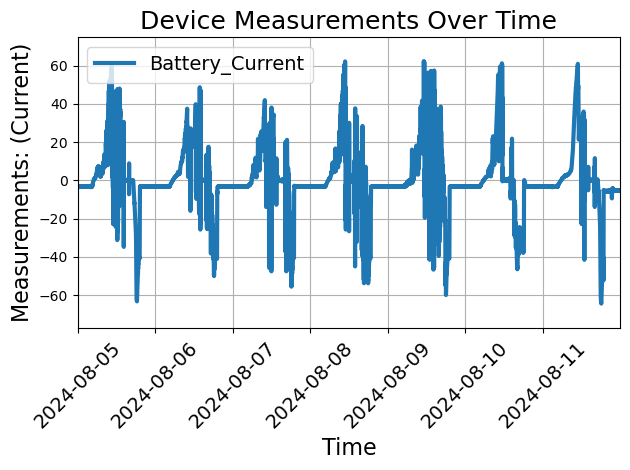

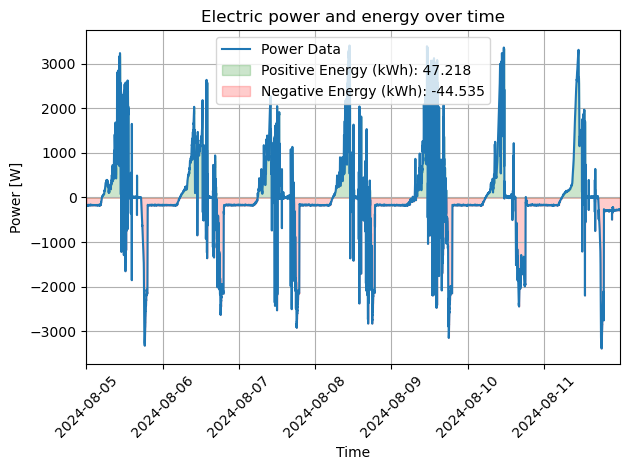

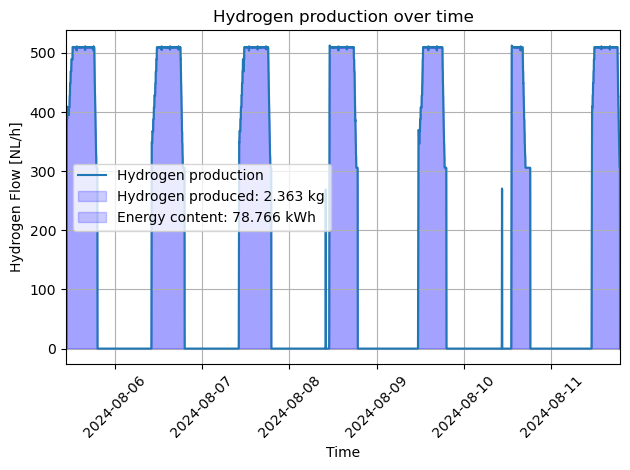

,time,value_float,device_id,measurement_id,application_id,name
0,2024-08-05 00:00:00+00:00,-3.340000,Battery,Current,Battery System,Seasonal_Storage_System
1,2024-08-05 00:01:00+00:00,-3.311667,Battery,Current,Battery System,Seasonal_Storage_System
2,2024-08-05 00:02:00+00:00,-3.261667,Battery,Current,Battery System,Seasonal_Storage_System
3,2024-08-05 00:03:00+00:00,-3.281667,Battery,Current,Battery System,Seasonal_Storage_System
4,2024-08-05 00:04:00+00:00,-3.300000,Battery,Current,Battery System,Seasonal_Storage_System


In [15]:

fplot('Battery_Current')

integrate_hr('Battery_Power')

integrate_h2('Electrolyser_Hydrogen_Flow_Rate')
Battery_Current.head()


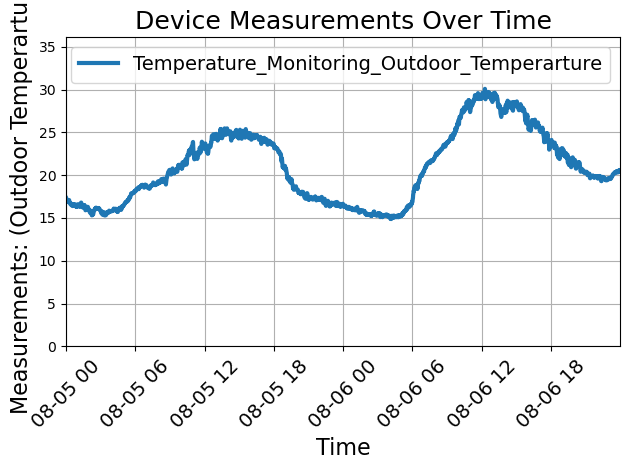

/var/folders/94/x7pykd1529z75np_t1jtxpzh0000gn/T/ipykernel_22958/2590961540.py:41: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(minval*1.2, maxval*1.2)


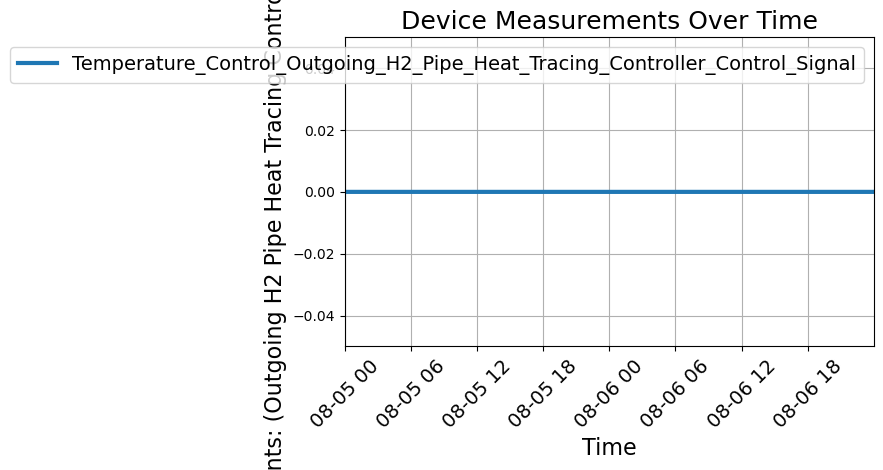

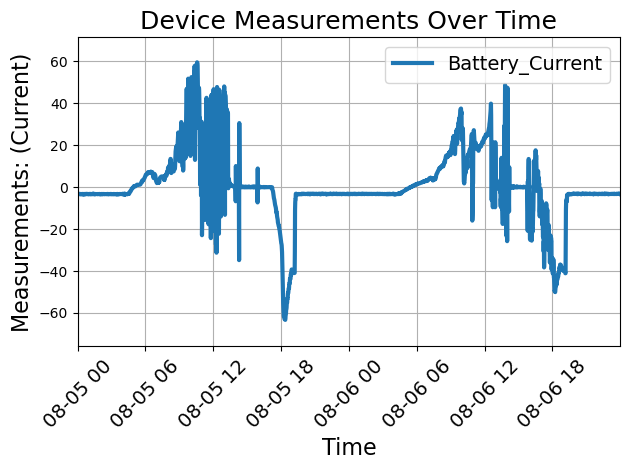

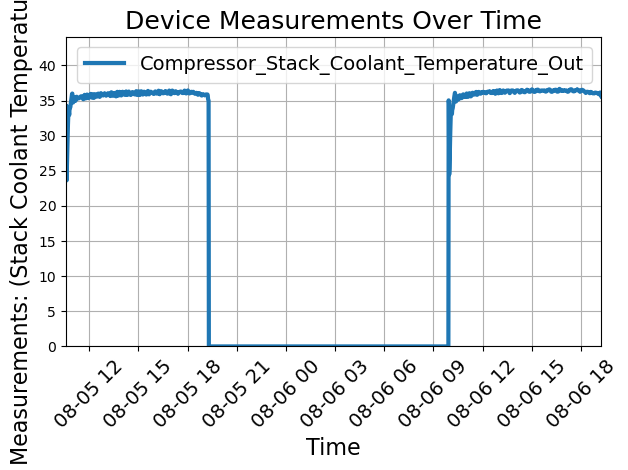

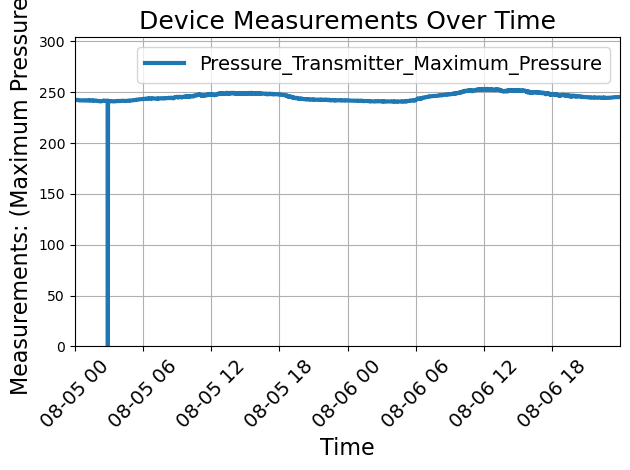

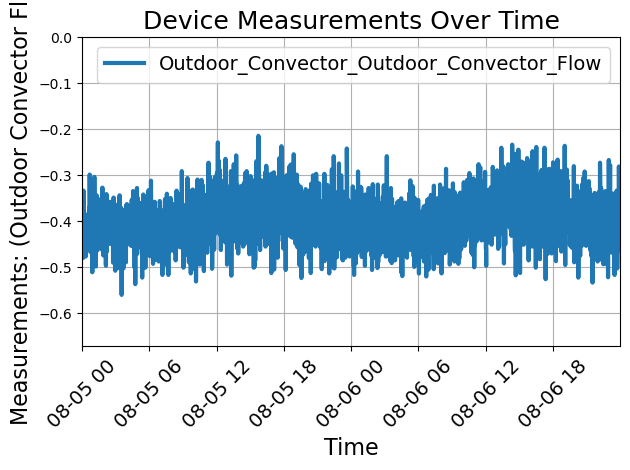

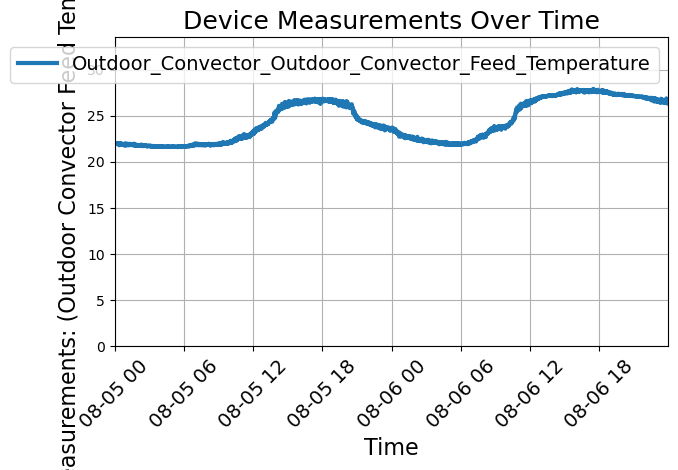

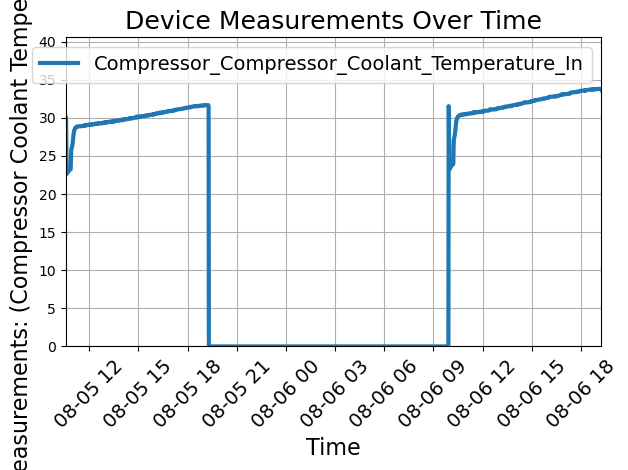

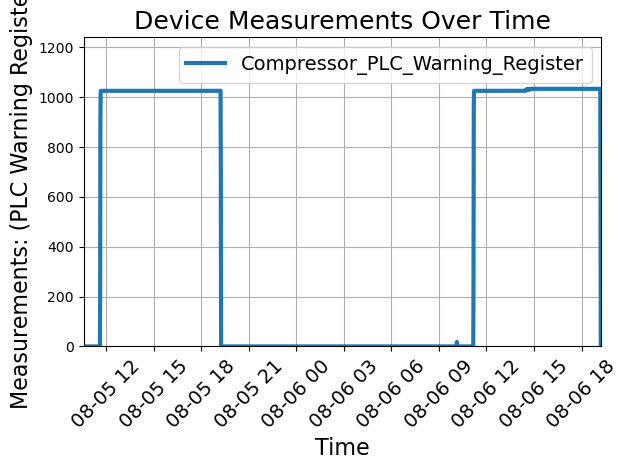

/var/folders/94/x7pykd1529z75np_t1jtxpzh0000gn/T/ipykernel_22958/2590961540.py:41: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(minval*1.2, maxval*1.2)


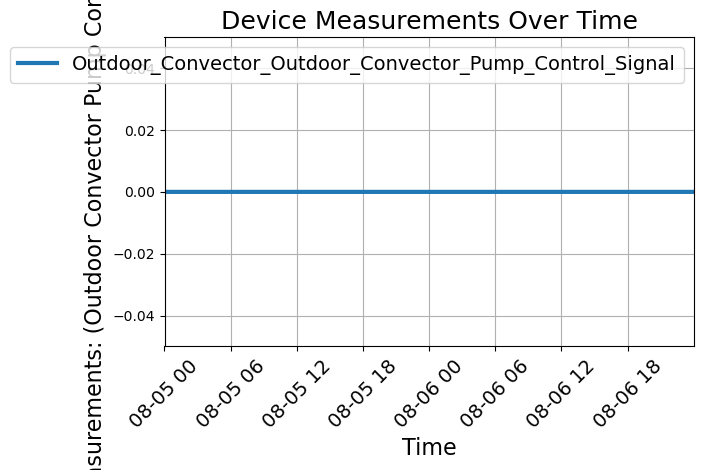

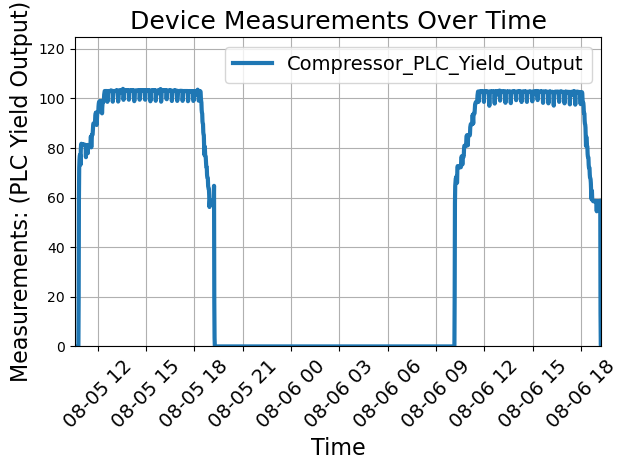

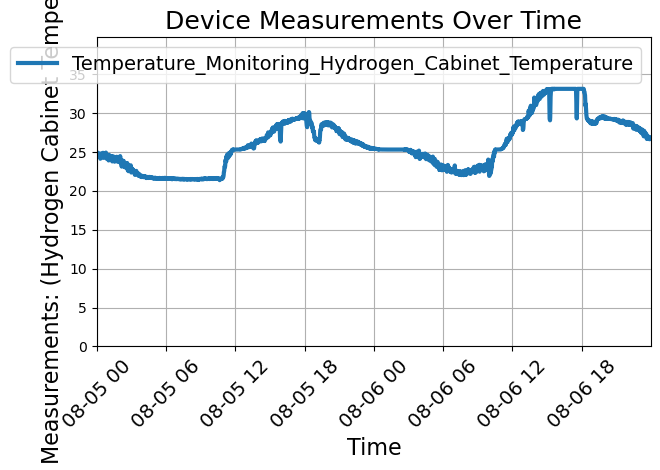

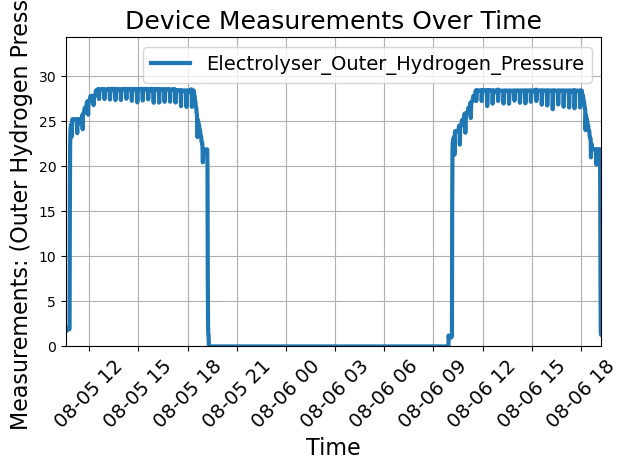

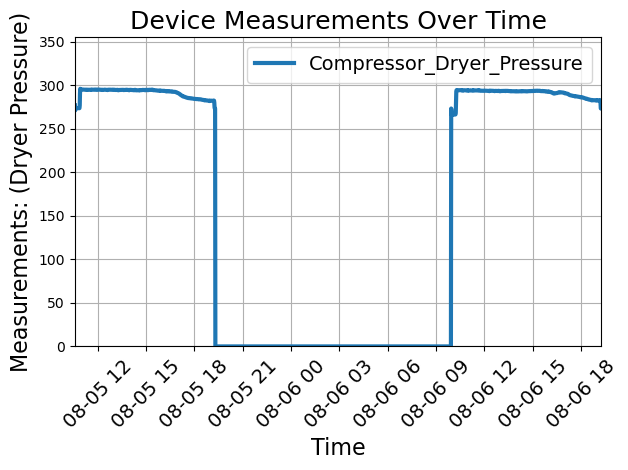

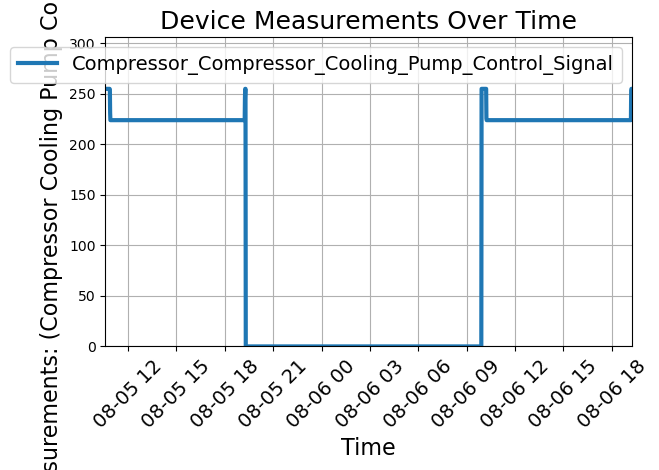

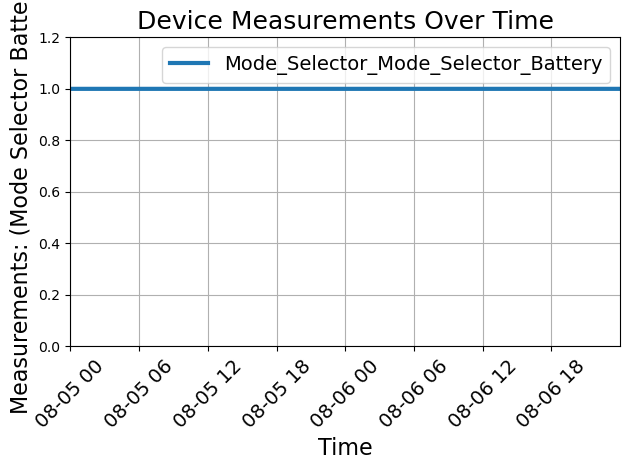

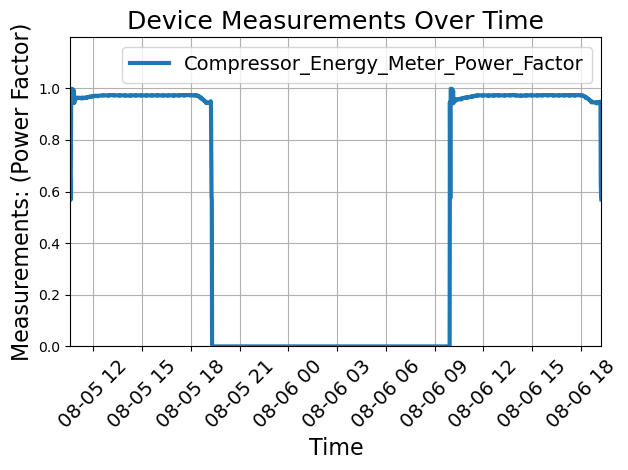

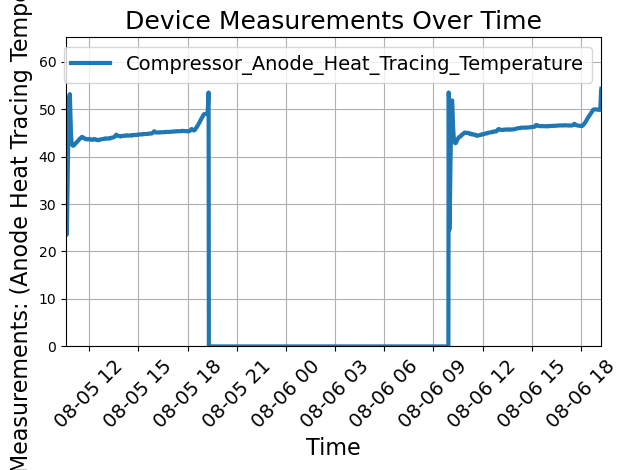

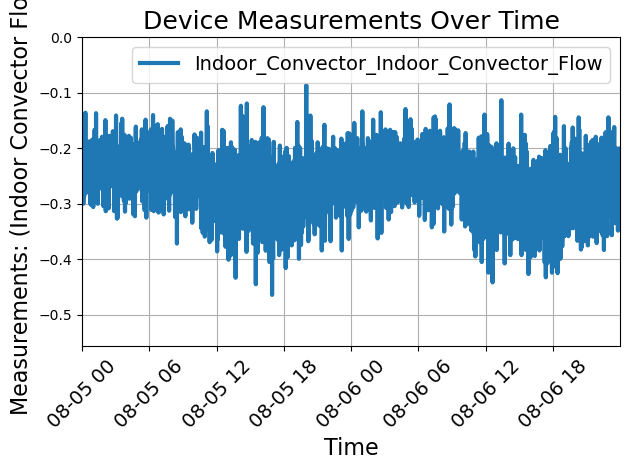

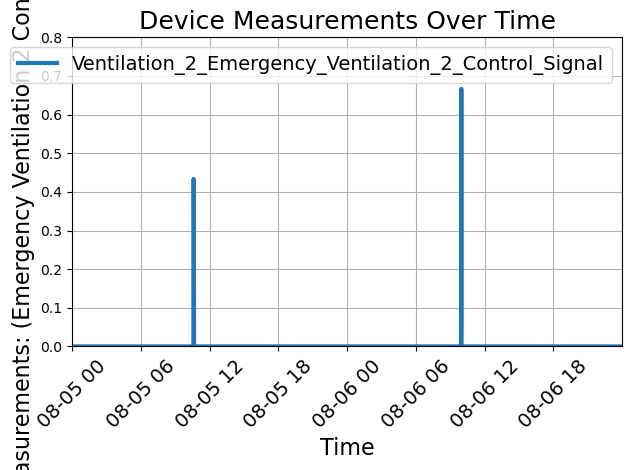

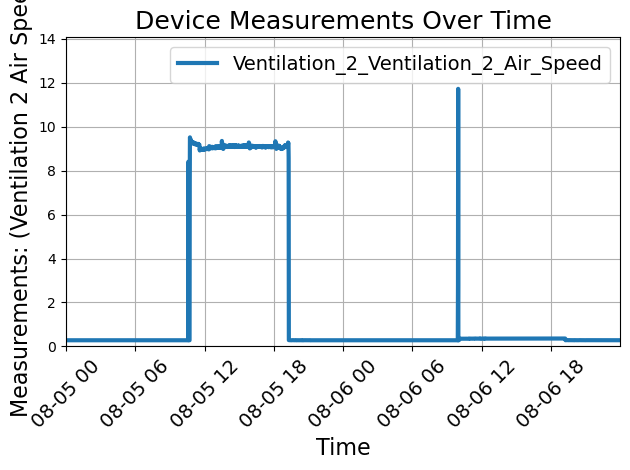

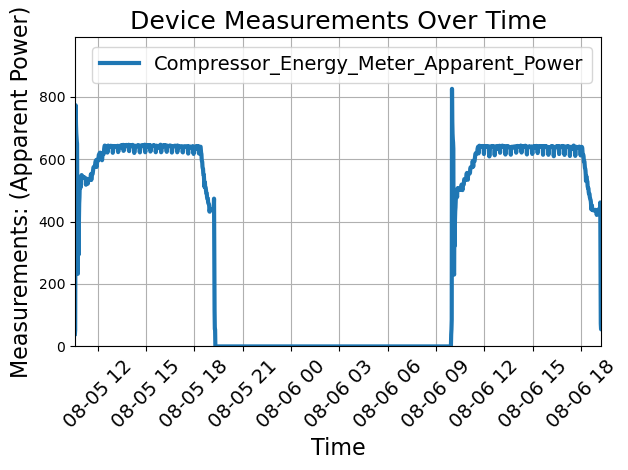

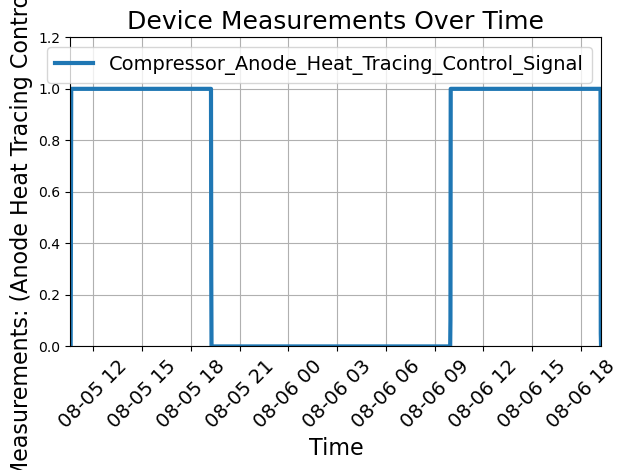

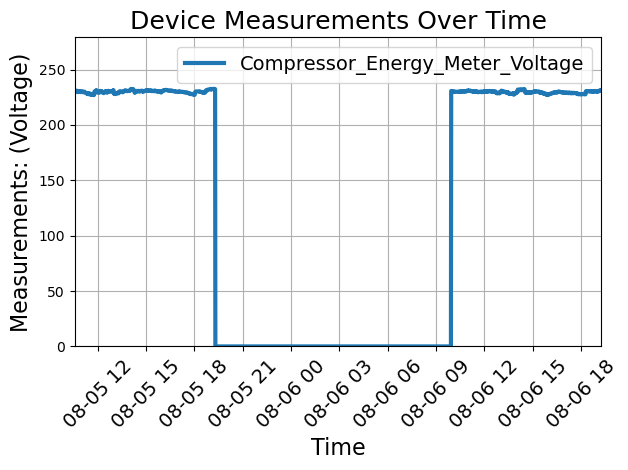

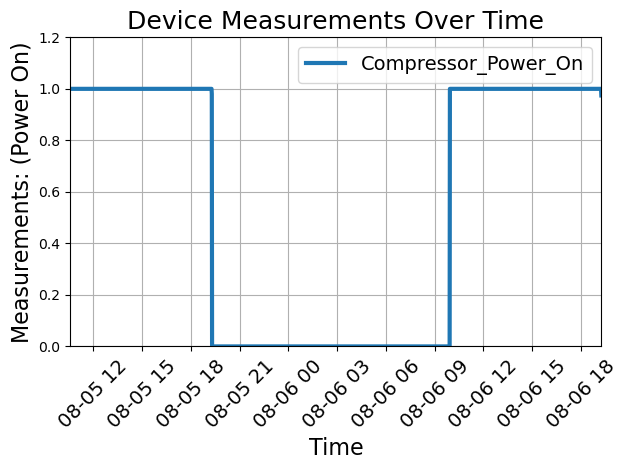

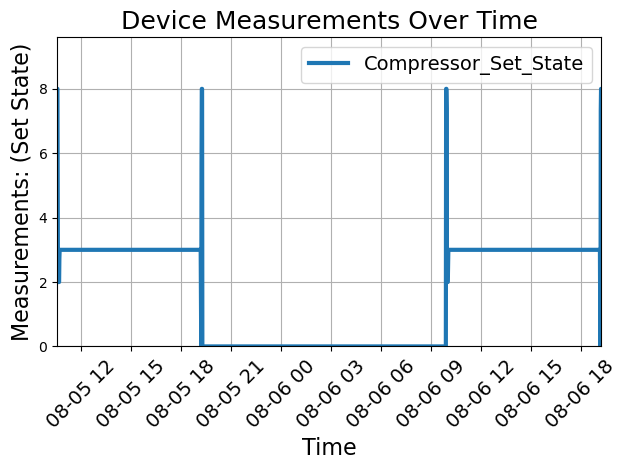

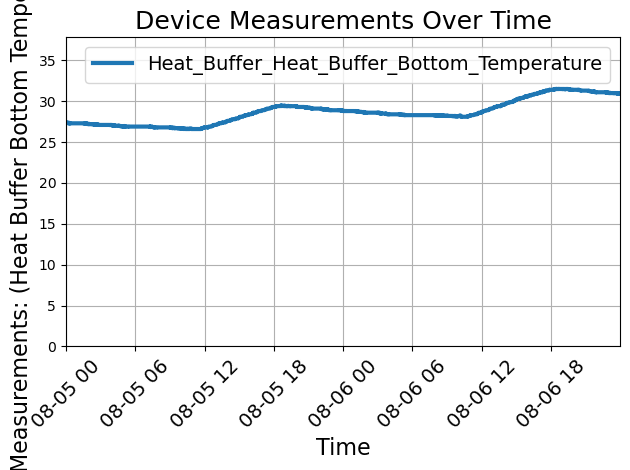

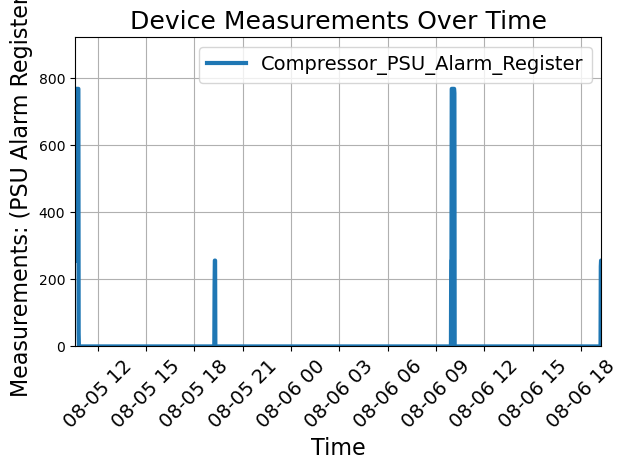

/var/folders/94/x7pykd1529z75np_t1jtxpzh0000gn/T/ipykernel_22958/2590961540.py:41: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(minval*1.2, maxval*1.2)


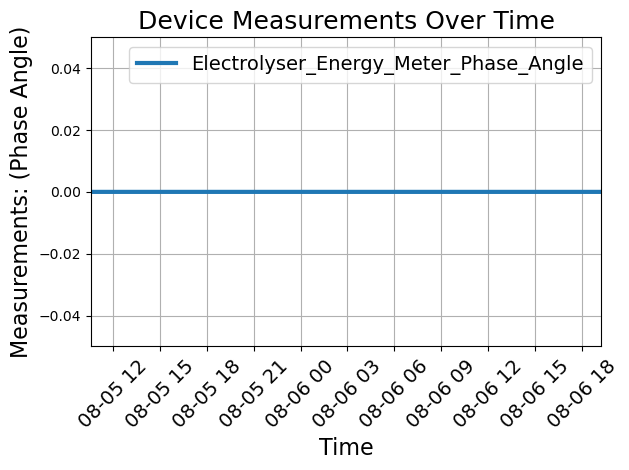

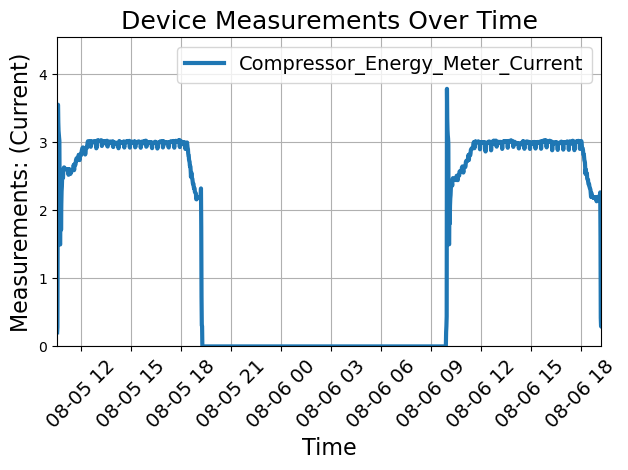

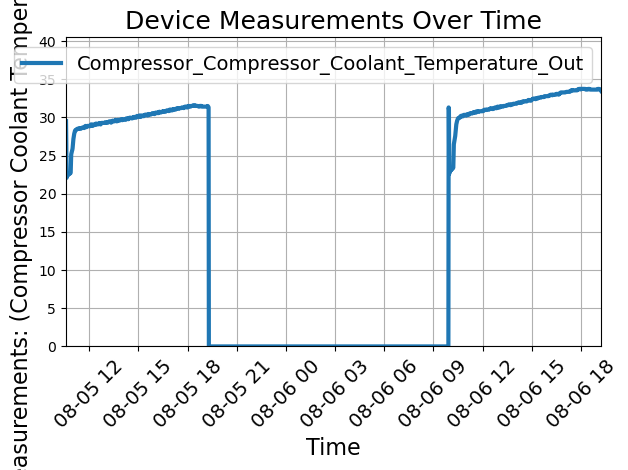

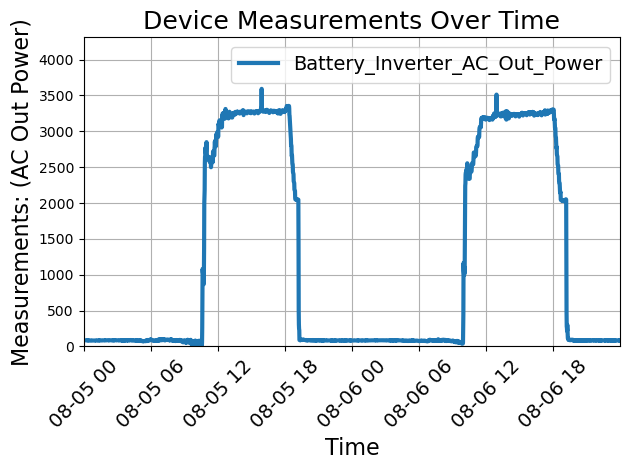

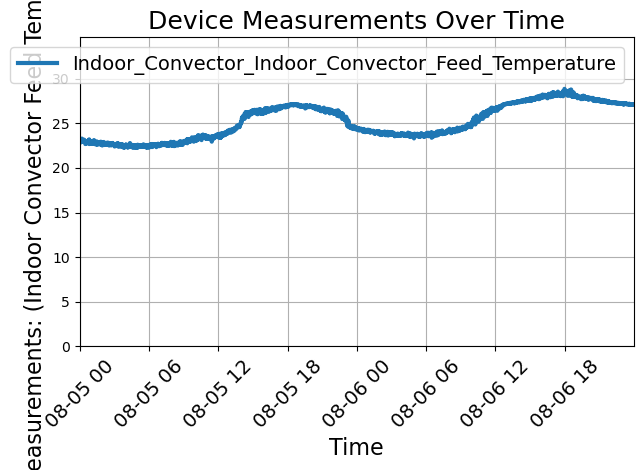

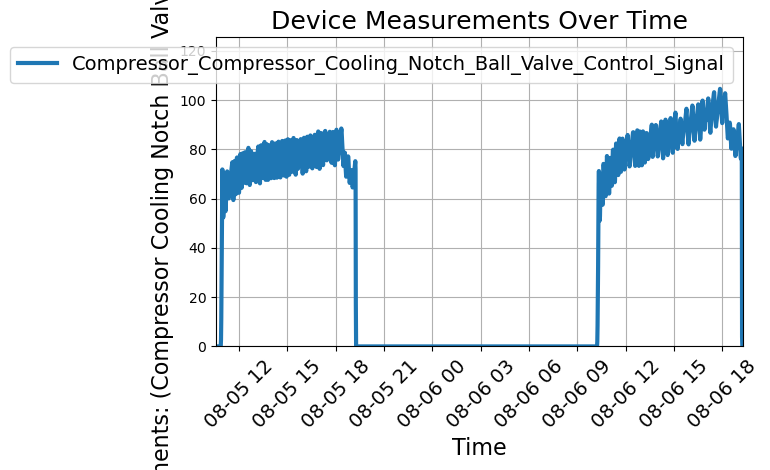

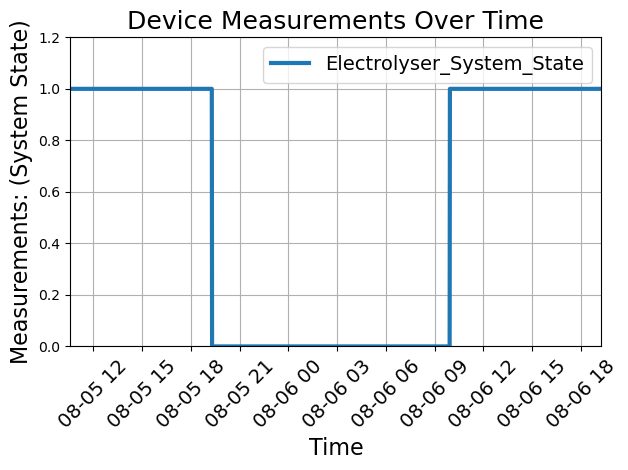

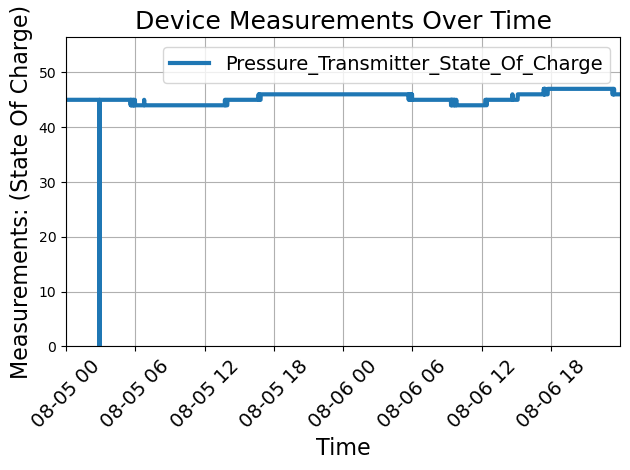

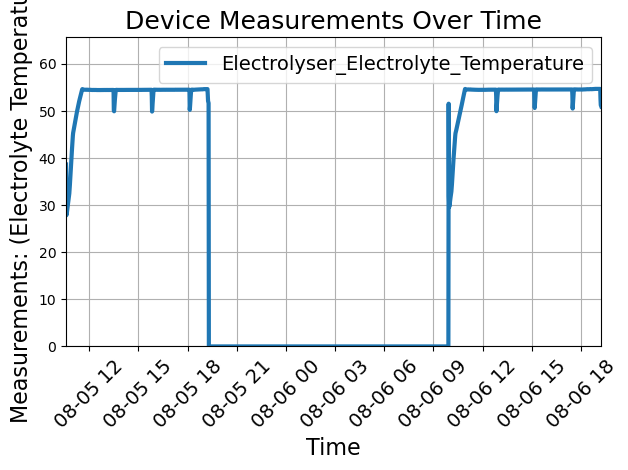

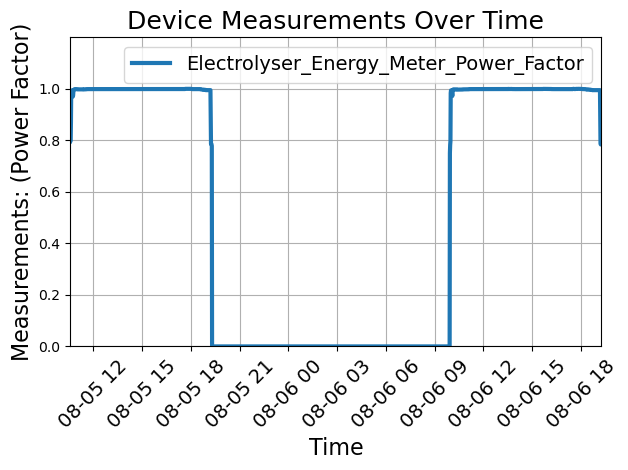

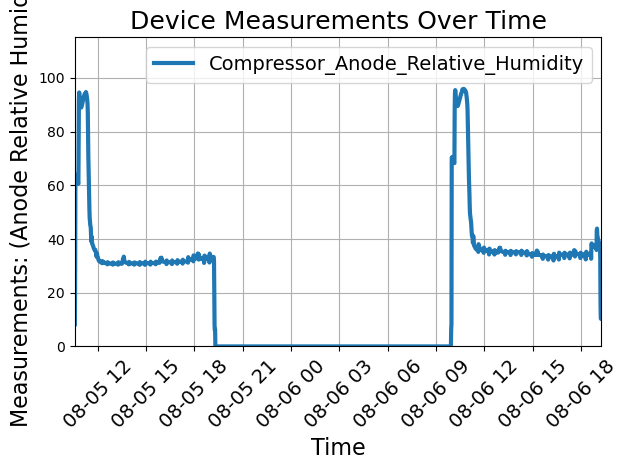

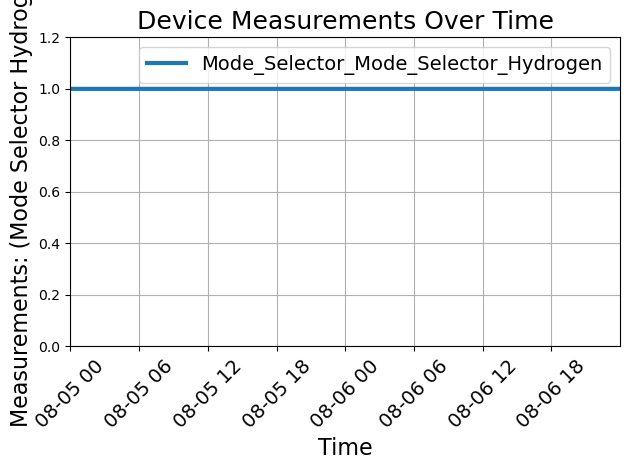

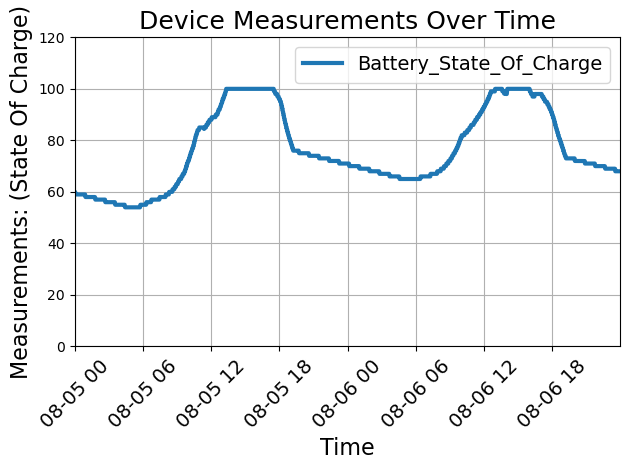

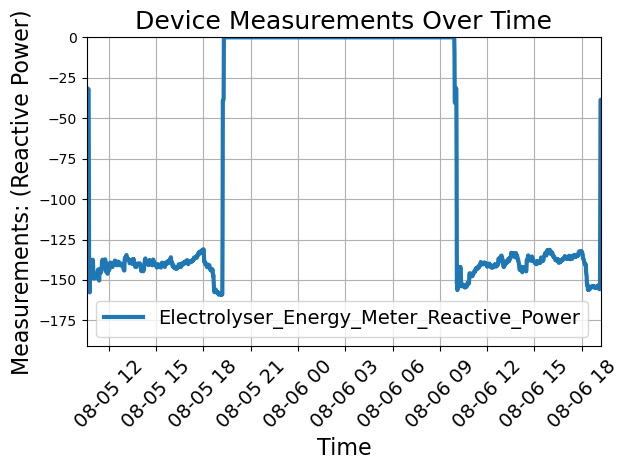

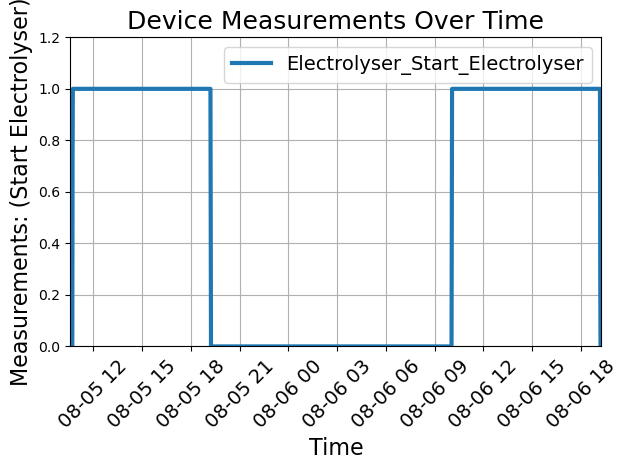

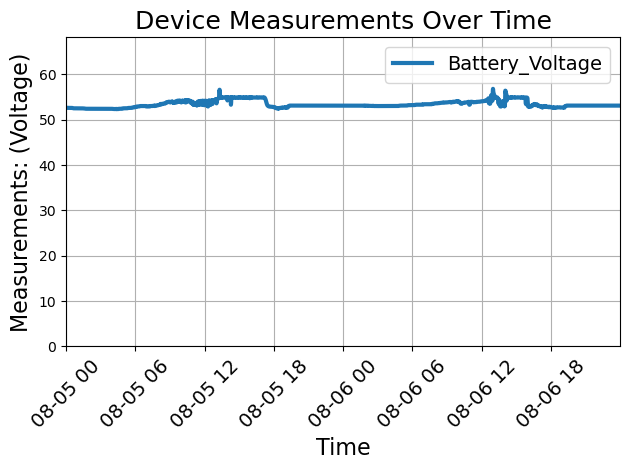

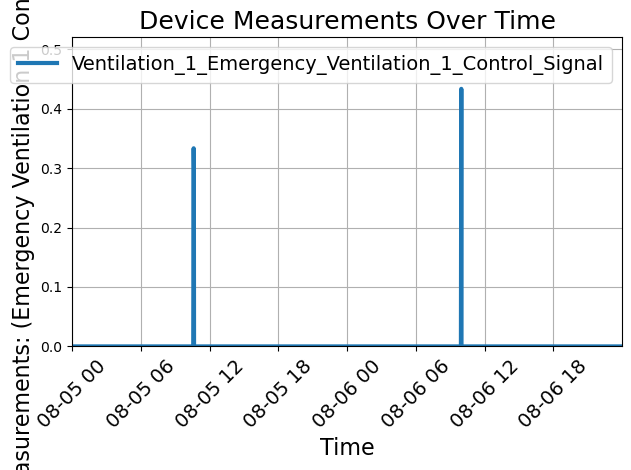

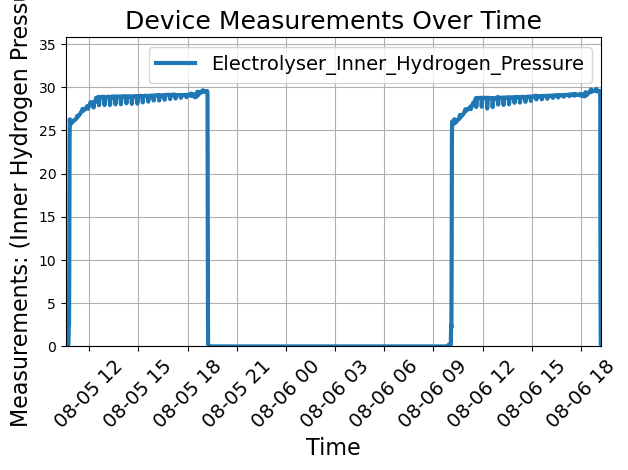

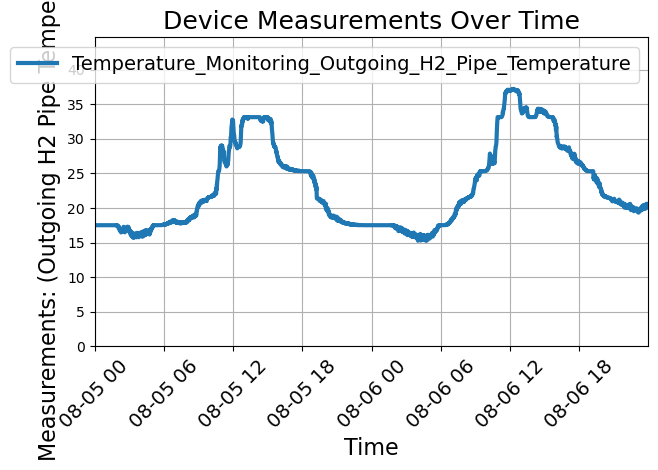

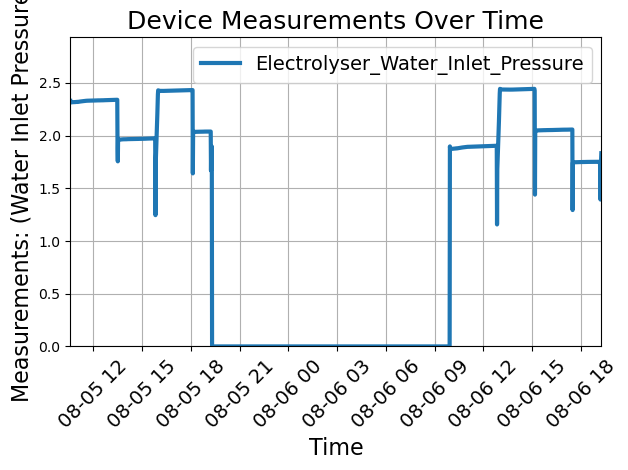

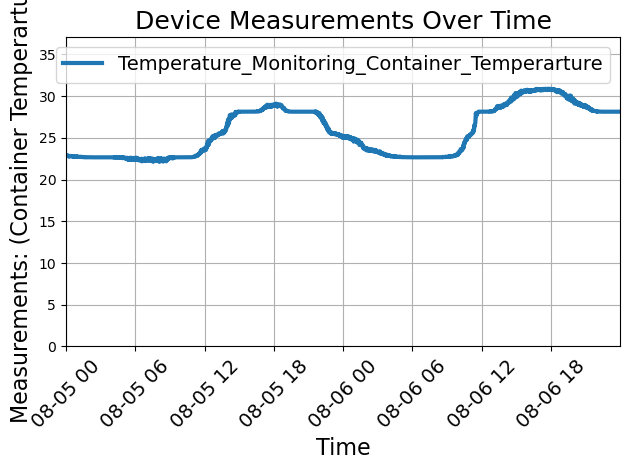

/var/folders/94/x7pykd1529z75np_t1jtxpzh0000gn/T/ipykernel_22958/2590961540.py:41: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(minval*1.2, maxval*1.2)


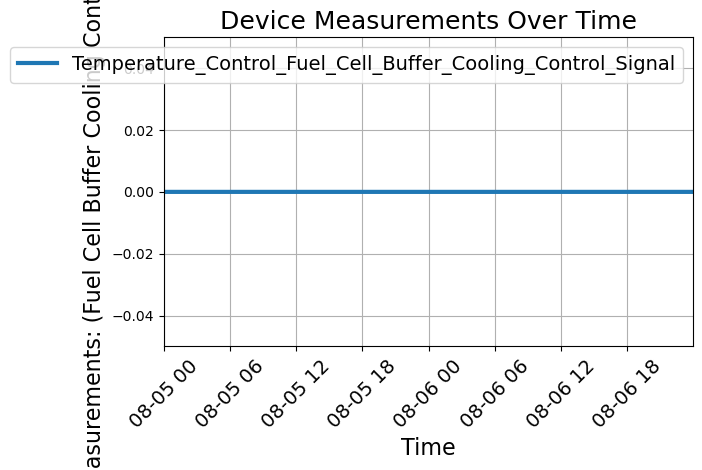

/var/folders/94/x7pykd1529z75np_t1jtxpzh0000gn/T/ipykernel_22958/2590961540.py:41: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(minval*1.2, maxval*1.2)


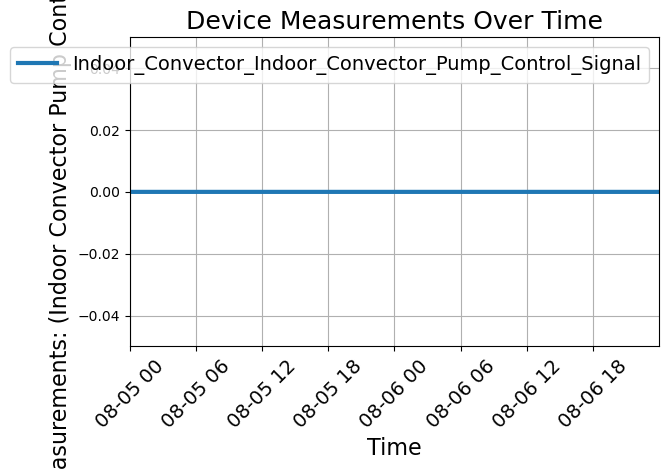

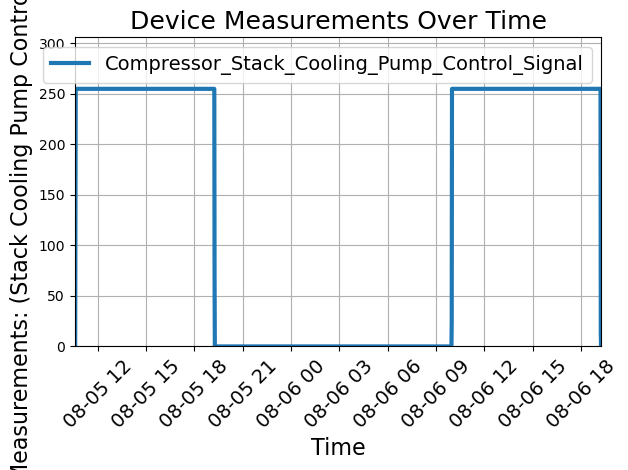

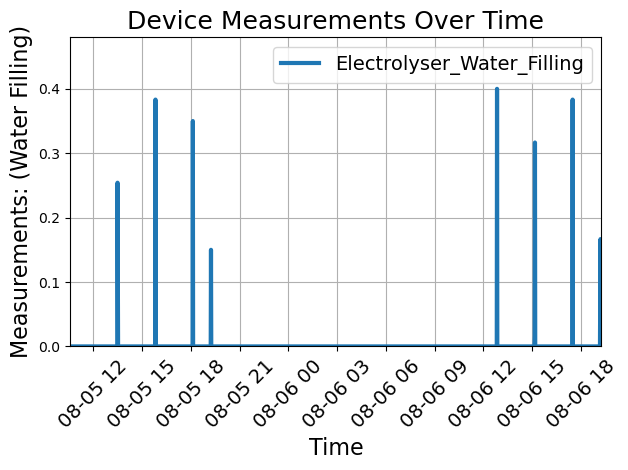

/var/folders/94/x7pykd1529z75np_t1jtxpzh0000gn/T/ipykernel_22958/2590961540.py:41: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(minval*1.2, maxval*1.2)


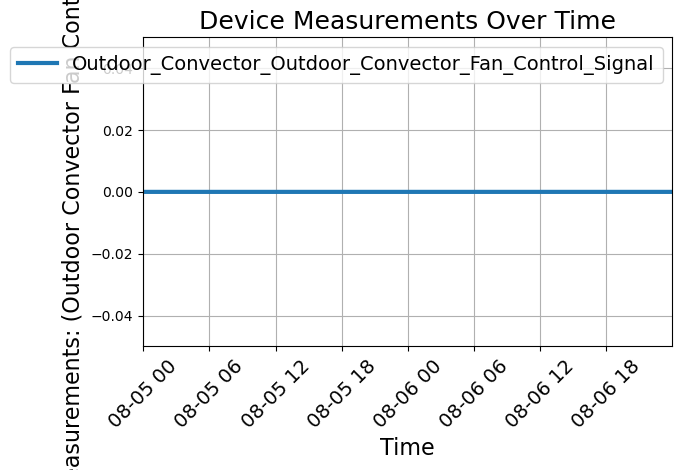

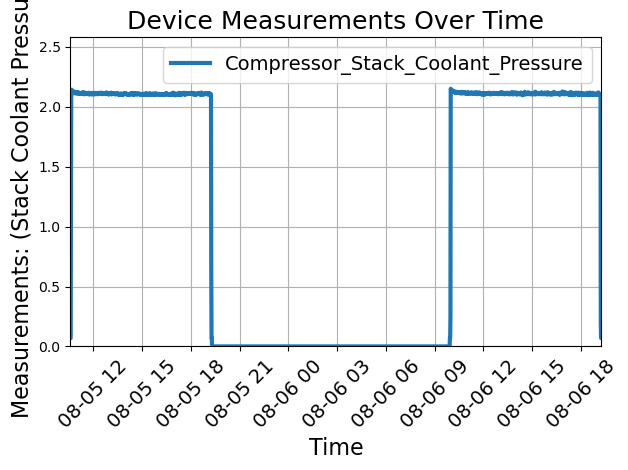

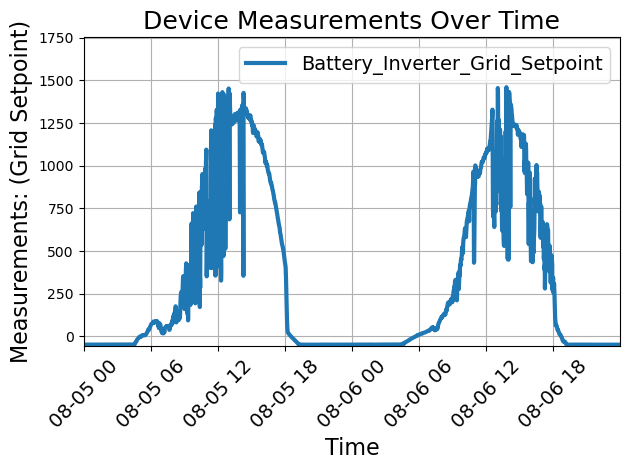

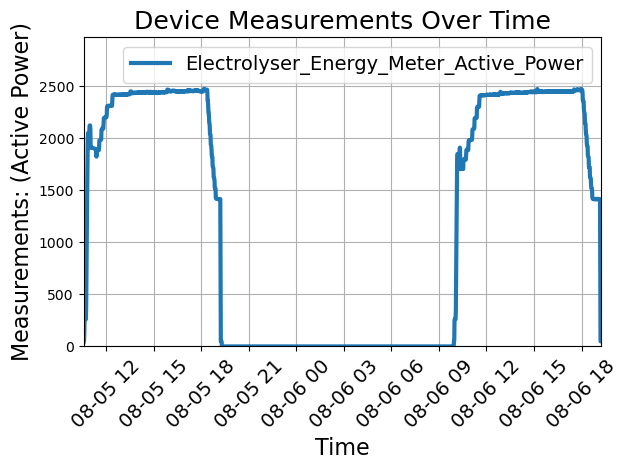

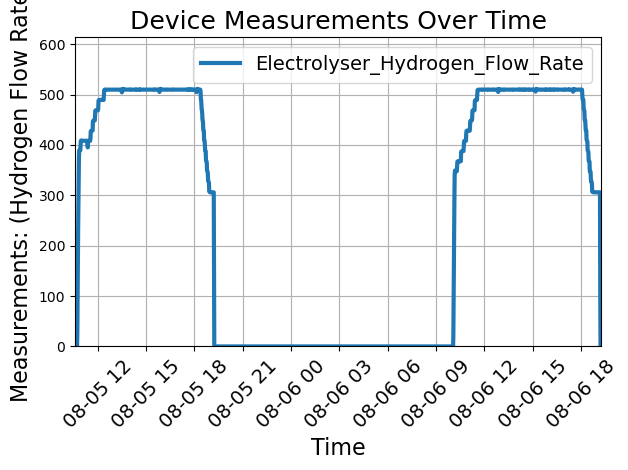

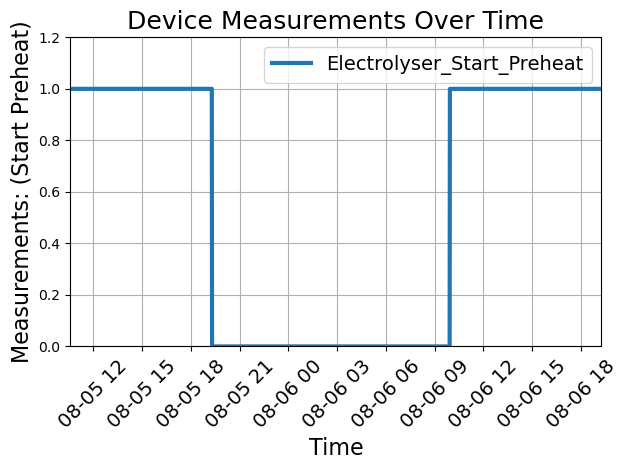

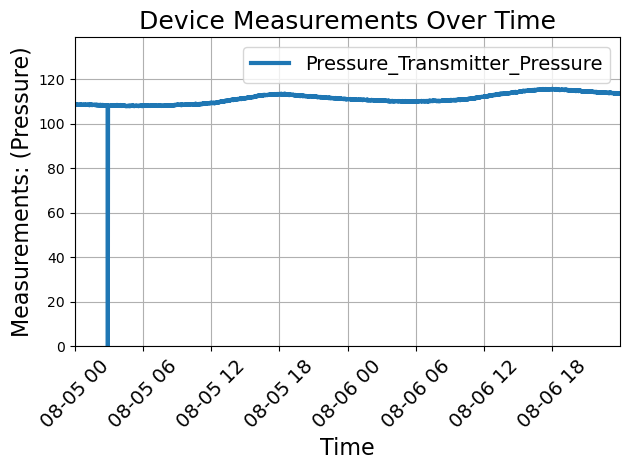

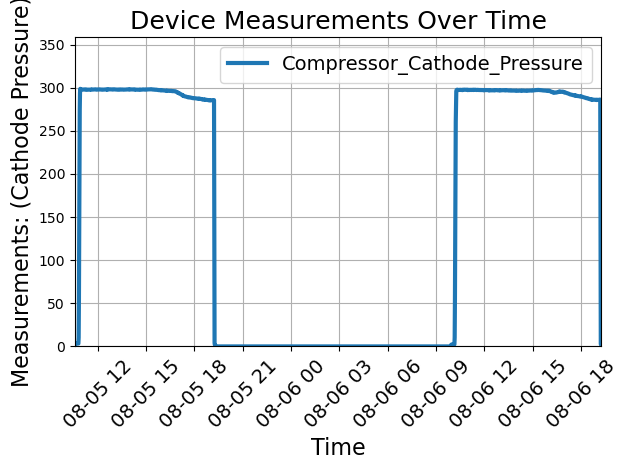

/var/folders/94/x7pykd1529z75np_t1jtxpzh0000gn/T/ipykernel_22958/2590961540.py:41: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(minval*1.2, maxval*1.2)


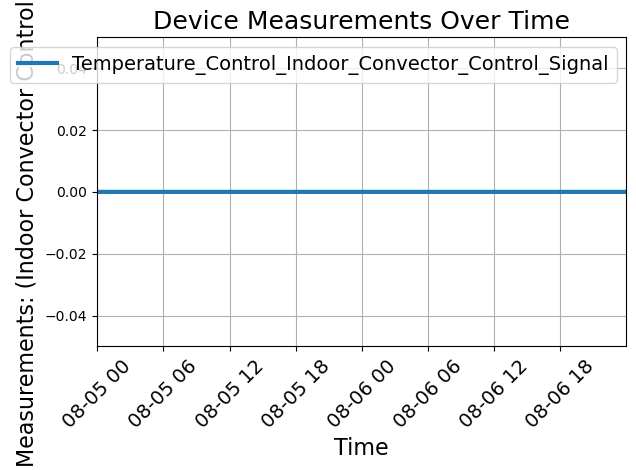

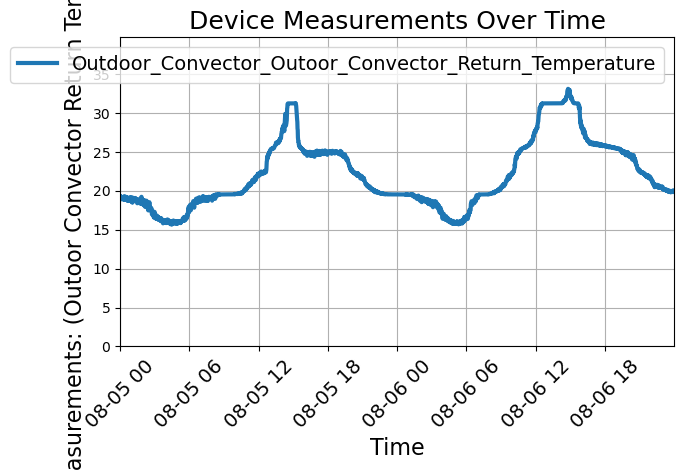

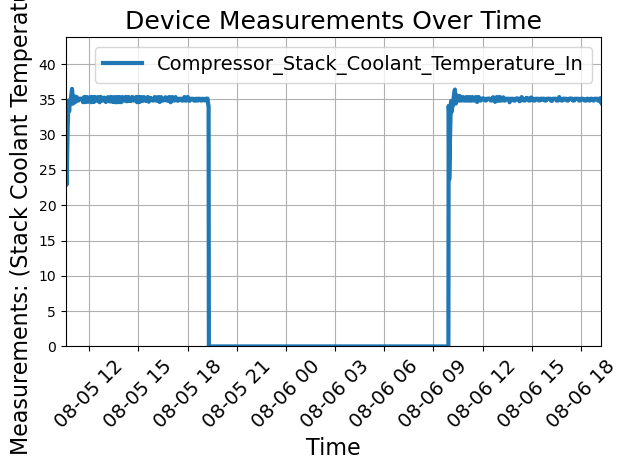

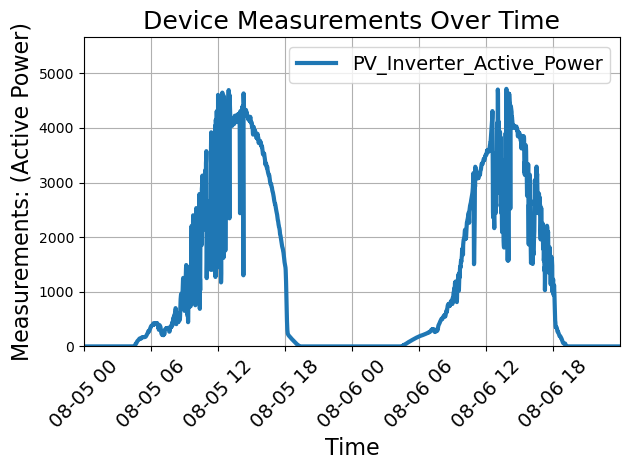

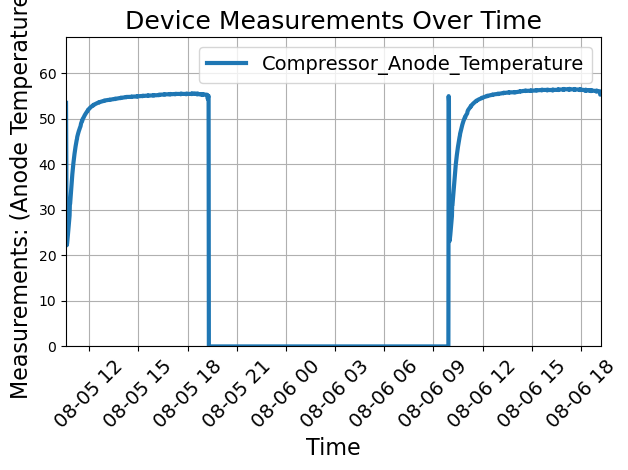

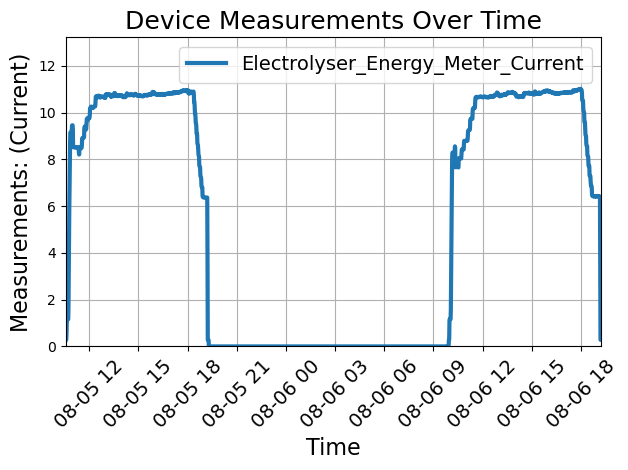

/var/folders/94/x7pykd1529z75np_t1jtxpzh0000gn/T/ipykernel_22958/2590961540.py:41: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(minval*1.2, maxval*1.2)


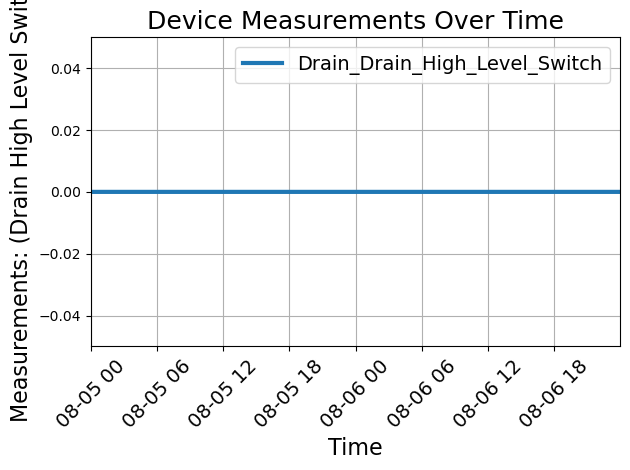

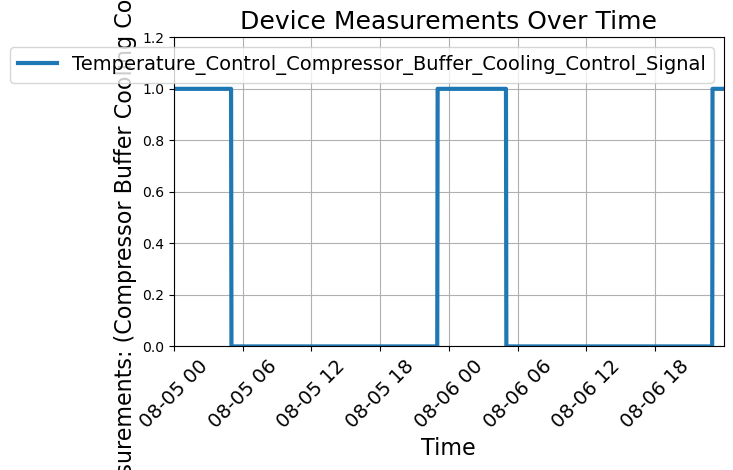

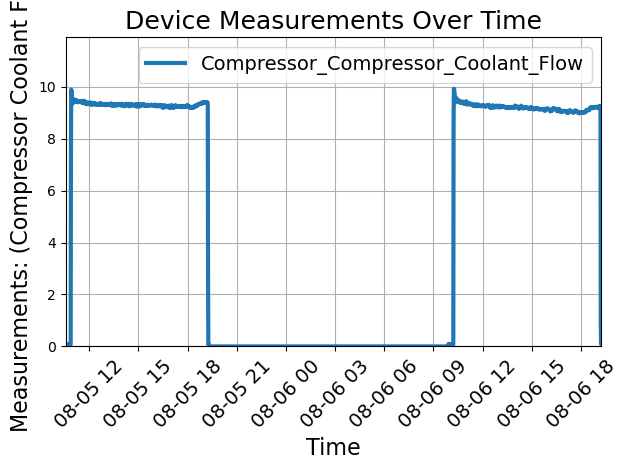

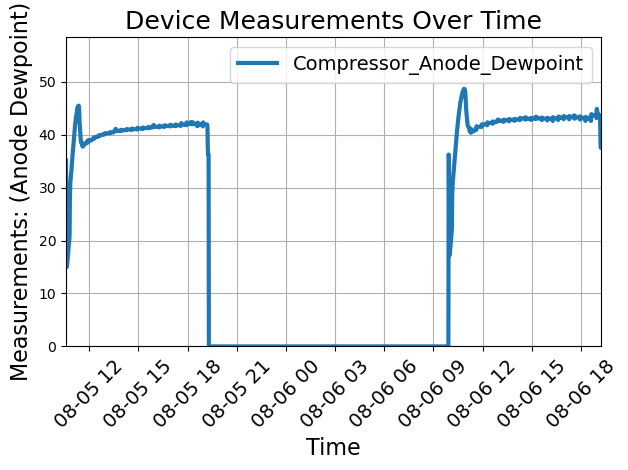

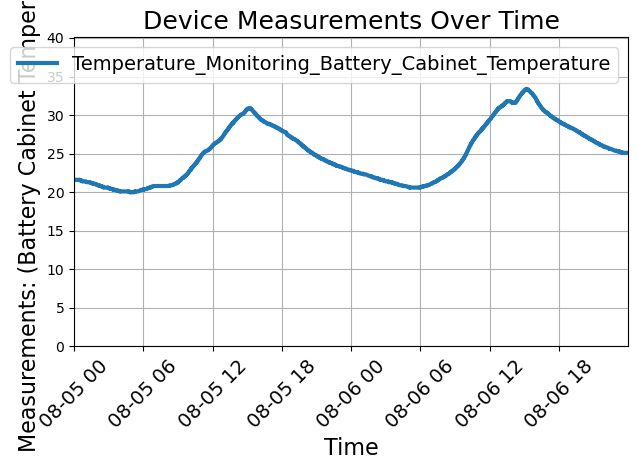

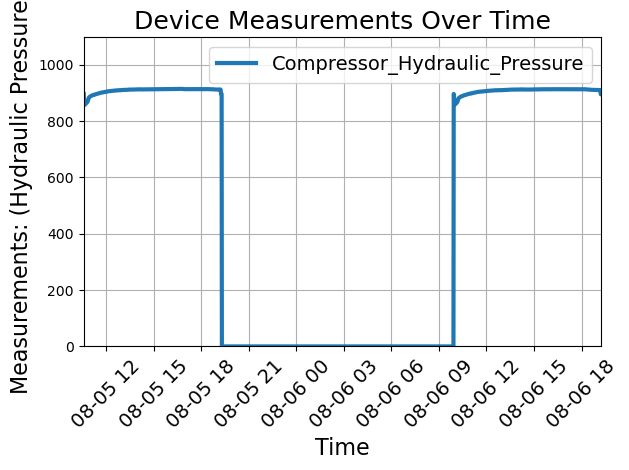

/var/folders/94/x7pykd1529z75np_t1jtxpzh0000gn/T/ipykernel_22958/2590961540.py:41: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(minval*1.2, maxval*1.2)


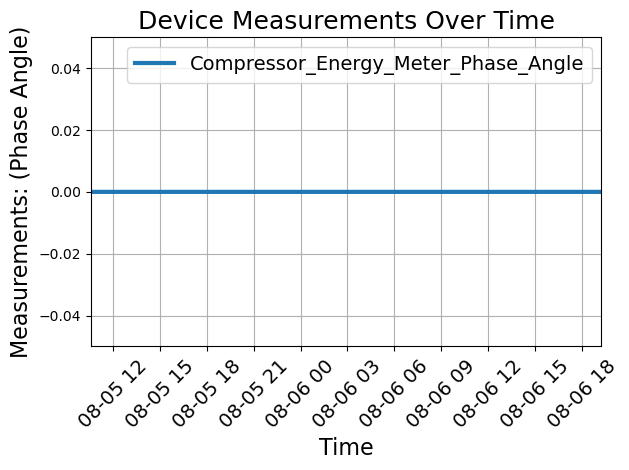

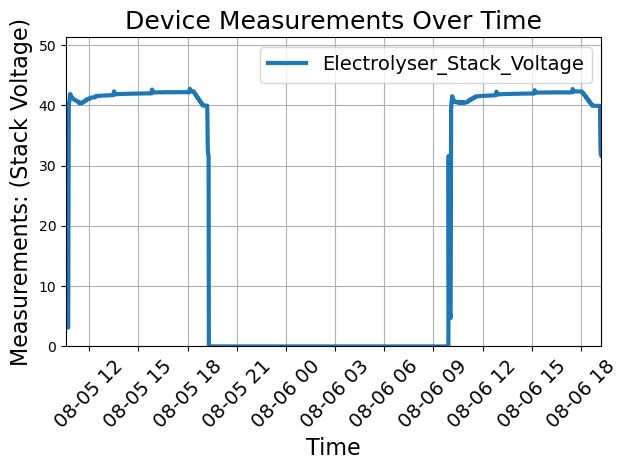

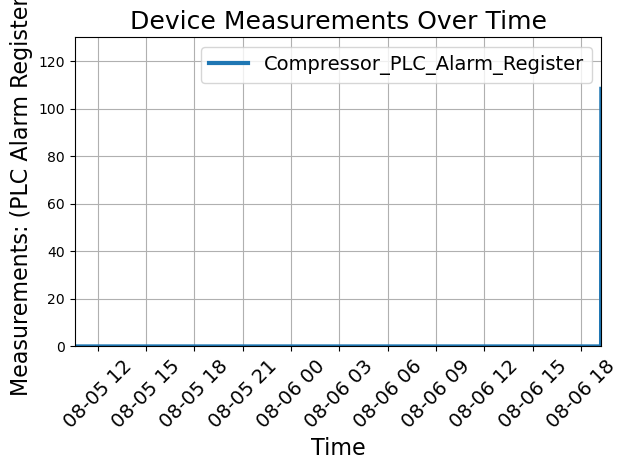

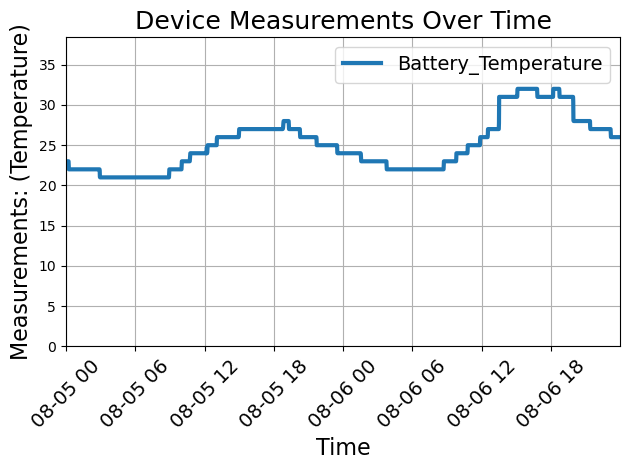

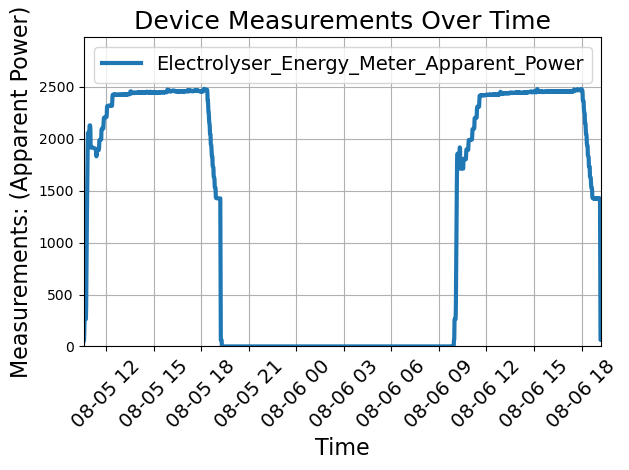

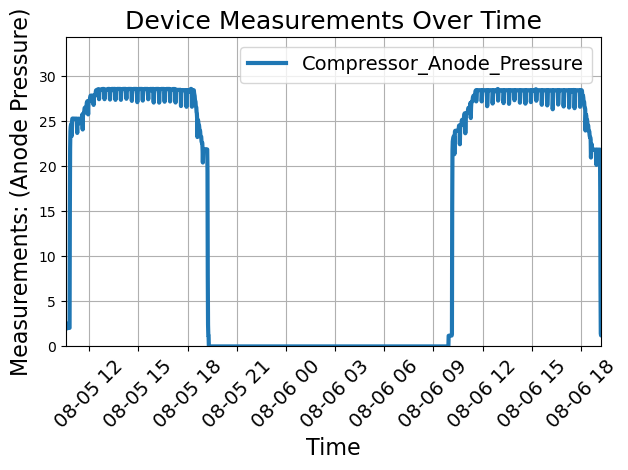

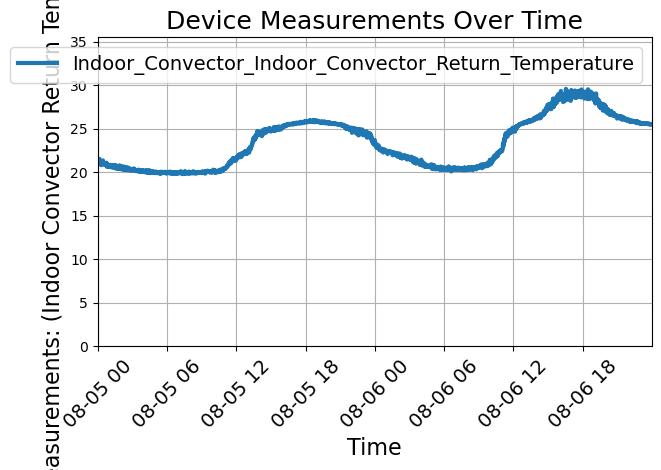

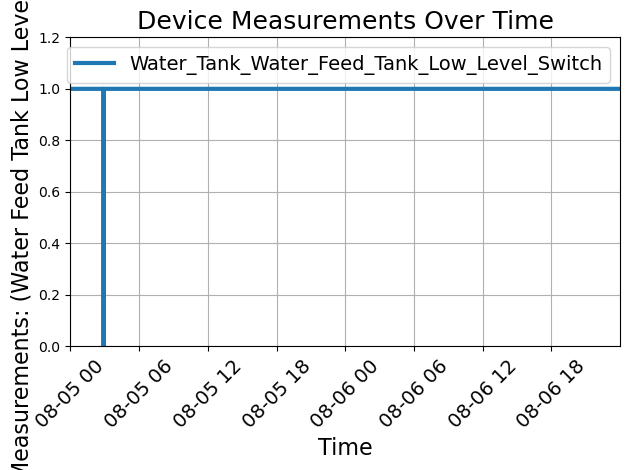

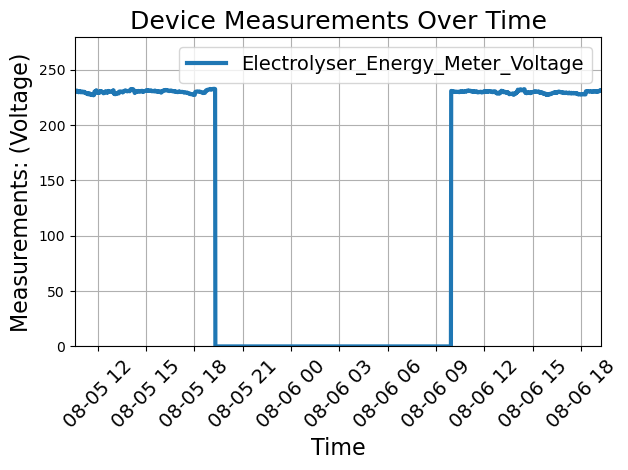

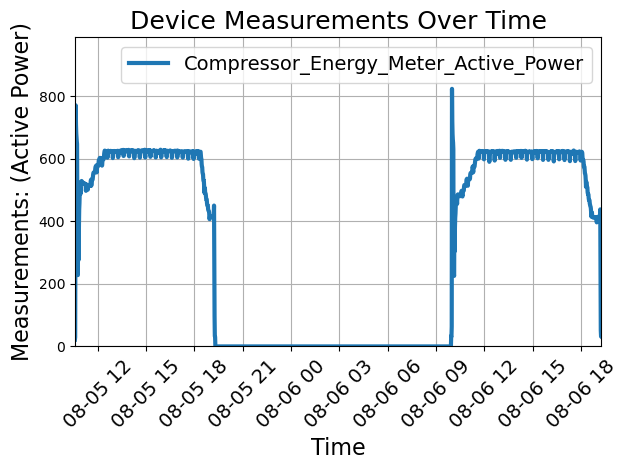

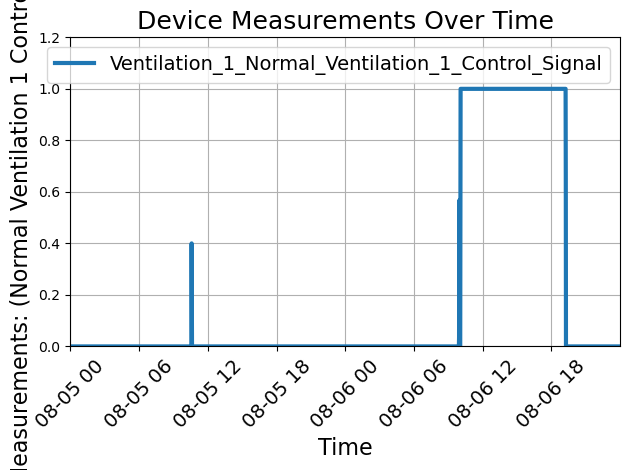

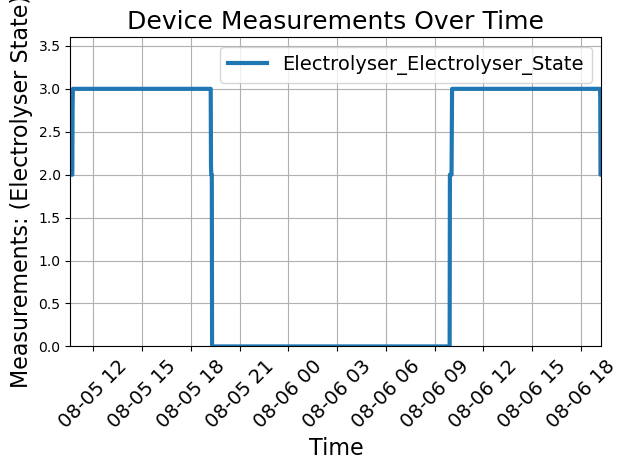

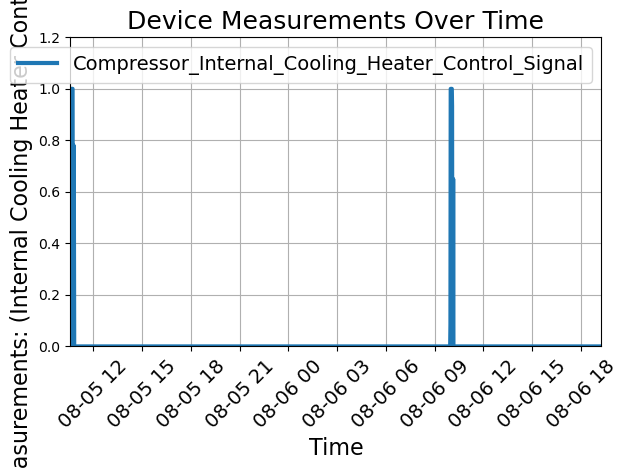

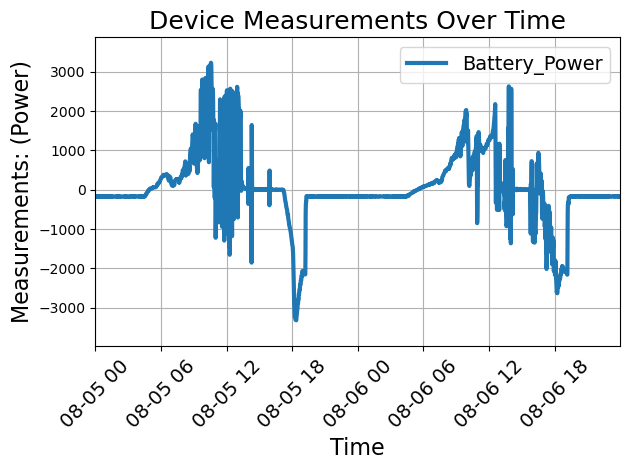

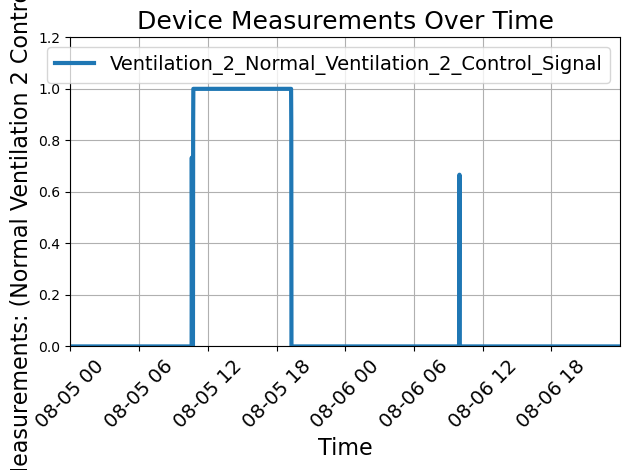

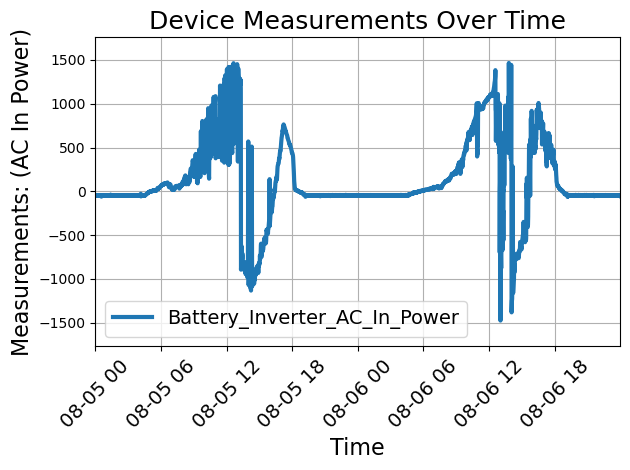

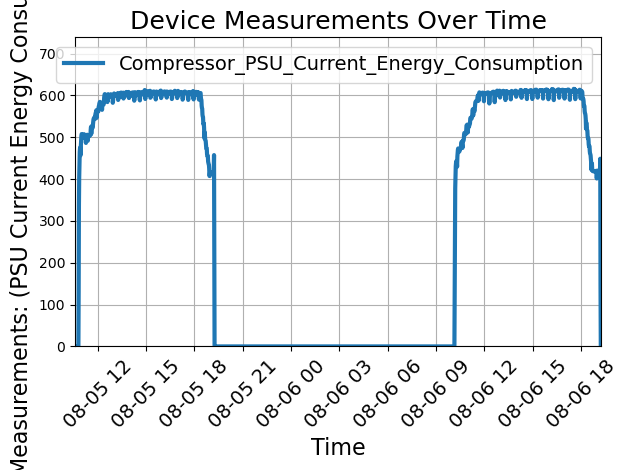

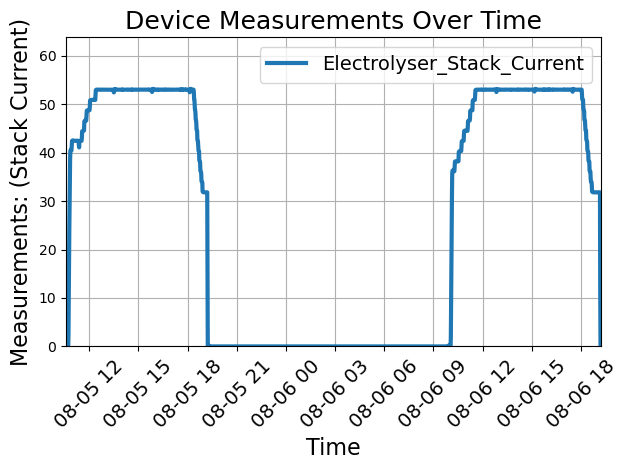

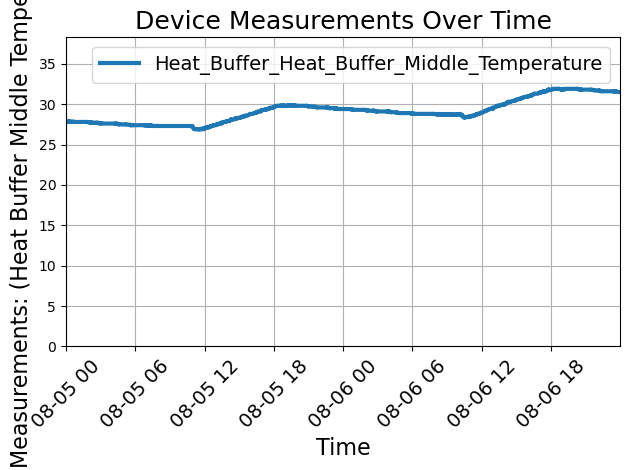

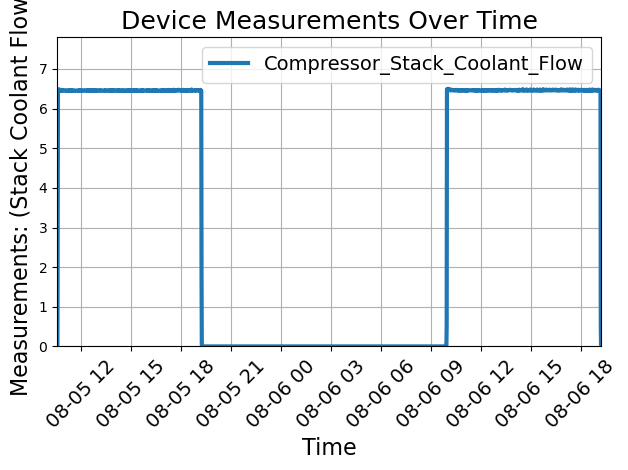

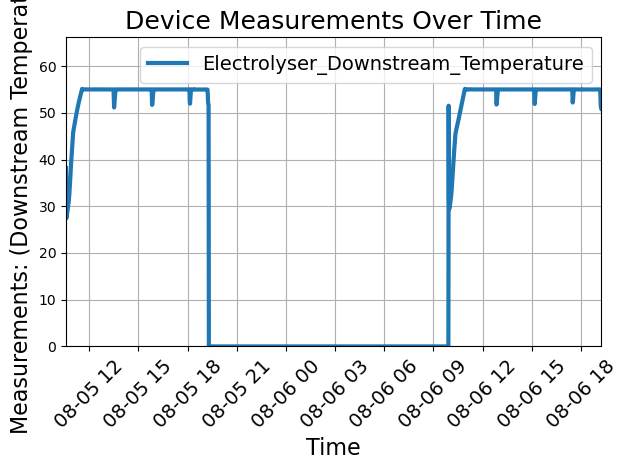

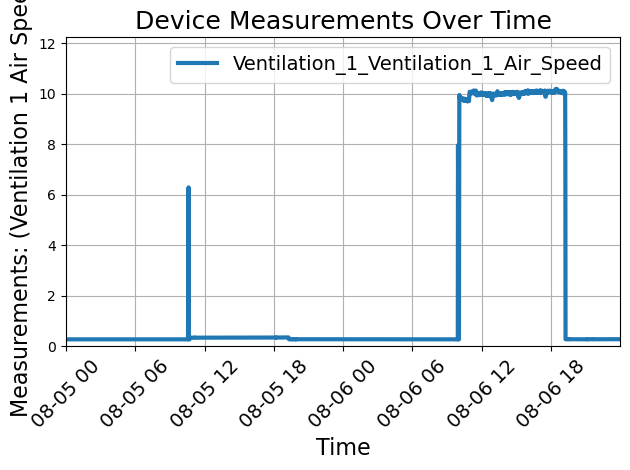

/var/folders/94/x7pykd1529z75np_t1jtxpzh0000gn/T/ipykernel_22958/2590961540.py:41: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(minval*1.2, maxval*1.2)


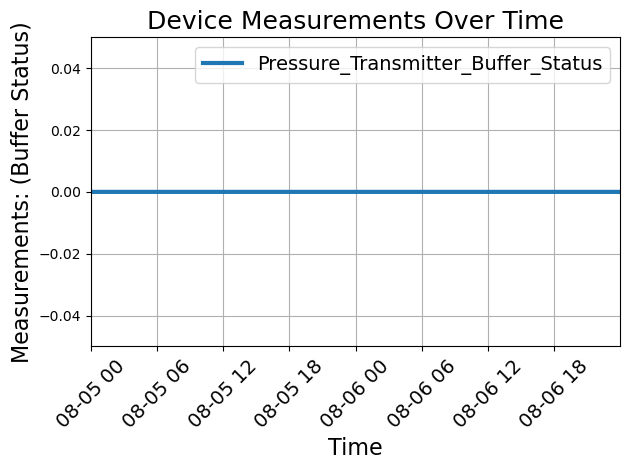

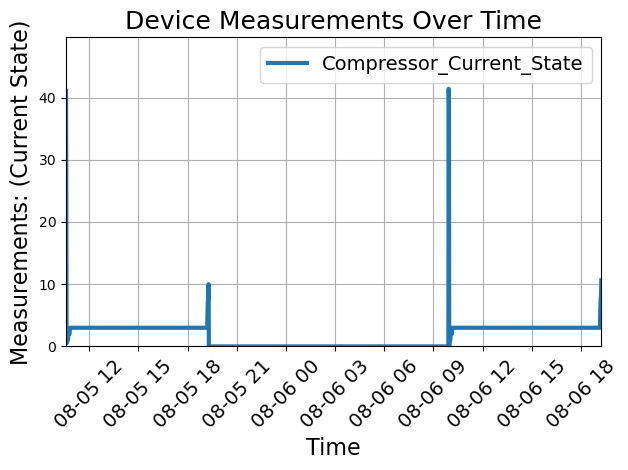

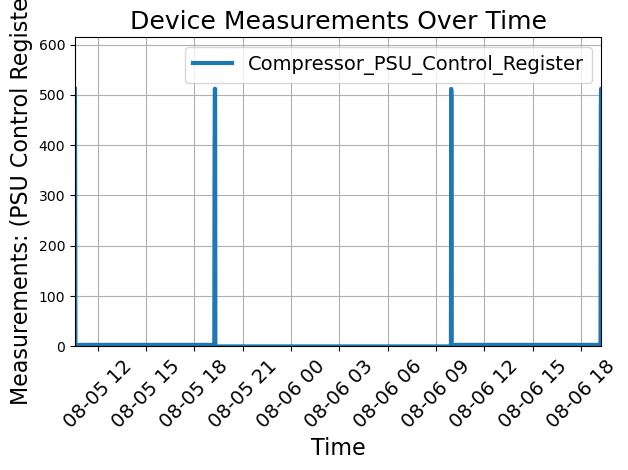

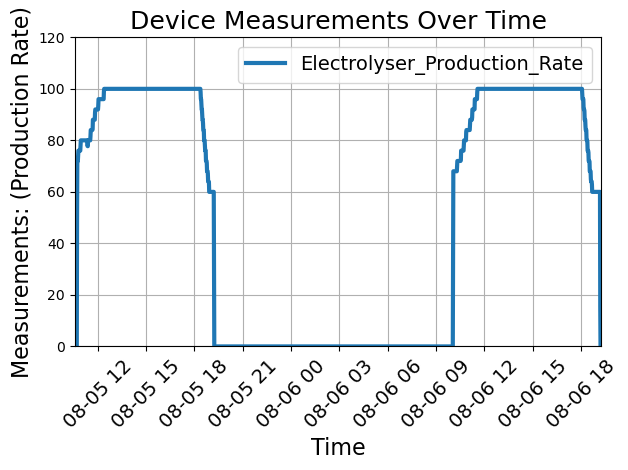

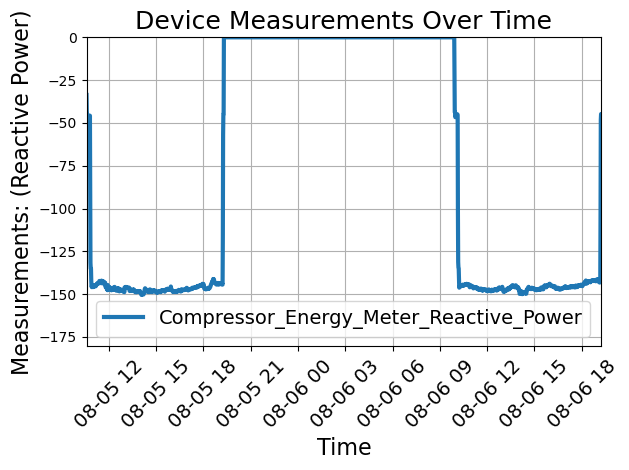

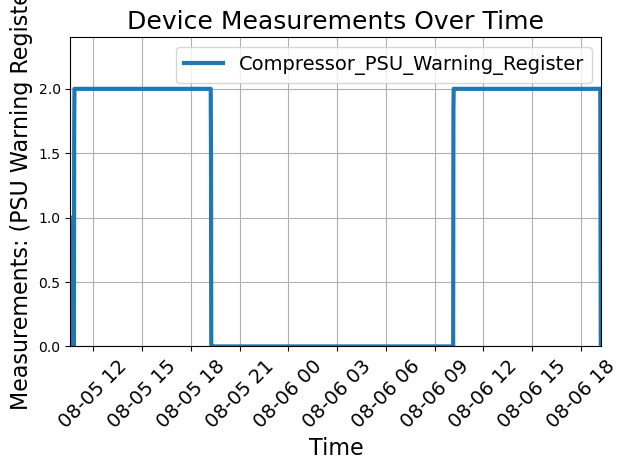

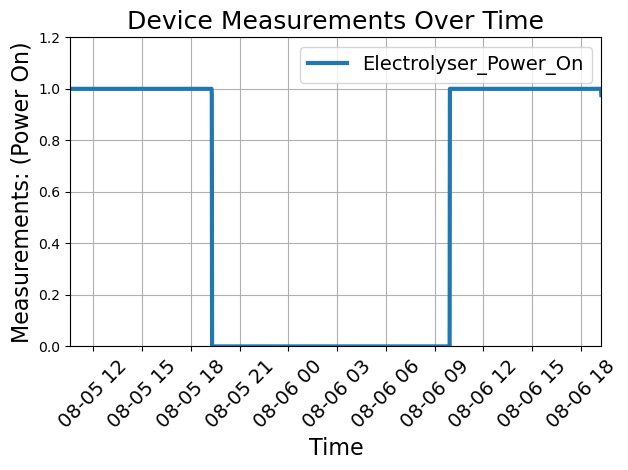

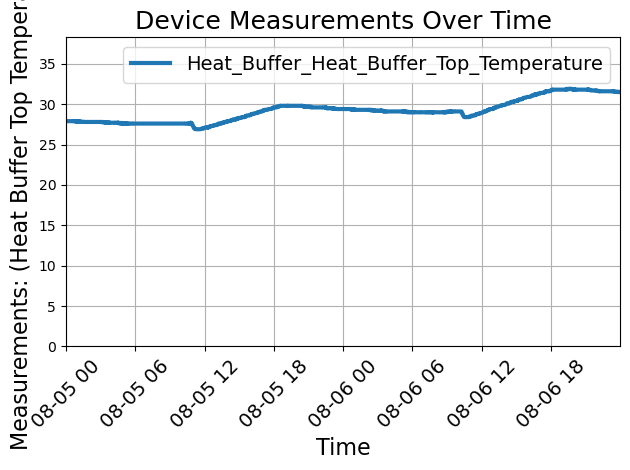

In [17]:
# Plot all dataframes to see if sampling was done right:
for var in DataframesToLoad:
    globals()[var] = pd.read_pickle(os.path.join(subfolder, f"{var}.pkl"))
    fplot(var)